In [507]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency  
from scipy.stats import chi2
from scipy.stats import pearsonr
import scipy.stats as stats



In [508]:
data = pd.read_csv('data/20260512-export.csv', sep=";")
display(data)

nb_reponses = len(data)

## SUPPRESSION DES QUESTIONNAIRES INCOMPLETS ##
data = data.dropna(subset=["Date_de_soumission"])
nb_reponses_completes = len(data)
nb_reponses_incompletes = nb_reponses - nb_reponses_completes

print("Nombre total de réponses :", nb_reponses)
print("Nombre de réponses complètes :", nb_reponses_completes)
print("Nombre de réponses incomplètes :", nb_reponses_incompletes)

,ID_de_la_réponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,Quel_est_votre_âge_?,Vous_êtes_:,Dans_quel_département_habitez-vous?,...,Durée_pour_le_groupe_:_En_pratique,Durée_pour_la_question:_prevention,Durée_pour_le_groupe_:_Cas_cliniques,Durée_pour_la_question:_reaction,Durée_pour_la_question:_cas1,Durée_pour_la_question:_cas2,Durée_pour_la_question:_cas3,Durée_pour_la_question:_cas4,Durée_pour_le_groupe_:_En_apprendre_d'avantage...,Durée_pour_la_question:_ensavoirplus
0,3,NaN,NaN,fr,1358314407,2025-10-10 11:54:17,2025-10-10 11:54:17,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30.0,Féminin,44.0,...,61.75,NaN,201.94,NaN,NaN,NaN,NaN,NaN,5.76,NaN
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31.0,Féminin,37.0,...,63.75,NaN,160.07,NaN,NaN,NaN,NaN,NaN,6.82,NaN
3,6,NaN,NaN,fr,988052067,2025-10-10 18:13:03,2025-10-10 18:13:03,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39.0,Féminin,97.0,...,84.13,NaN,254.48,NaN,NaN,NaN,NaN,NaN,11.75,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,559,2026-05-05 22:13:45,5.0,fr,1653017331,2026-05-05 21:56:20,2026-05-05 22:13:45,41.0,Féminin,92.0,...,138.88,NaN,226.68,NaN,NaN,NaN,NaN,NaN,17.19,NaN
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23.0,Féminin,56.0,...,62.68,NaN,131.61,NaN,NaN,NaN,NaN,NaN,7.43,NaN
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30.0,Féminin,38.0,...,72.80,NaN,140.11,NaN,NaN,NaN,NaN,NaN,7.72,NaN
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31.0,Masculin,38.0,...,77.44,NaN,180.27,NaN,NaN,NaN,NaN,NaN,6.53,NaN


Nombre total de réponses : 558
Nombre de réponses complètes : 316
Nombre de réponses incomplètes : 242


In [509]:
list(data.columns)

['ID_de_la_réponse',
 'Date_de_soumission',
 'Dernière_page',
 'Langue_de_départ',
 'Tête_de_série',
 'Date_de_lancement',
 'Date_de_la_dernière_action',
 'Quel_est_votre_âge_?',
 'Vous_êtes_:',
 'Dans_quel_département_habitez-vous?',
 "Quel_est_votre_niveau_d'étude_?\xa0",
 'A_quel_niveau_social_vous_situez-vous,_selon-vous_?\xa0_[Niveau_social_]',
 'Avez-vous_des_difficultés_financières_?',
 'Fumez-vous_?_(autre_que_la_cigarette_électronique)',
 'Avez-vous_des_maladies_ou_des_problèmes_de_santé_durables?',
 'Avez-vous_une_formation_professionnalisante_dans_le_domaine_de_la_santé?',
 'Travaillez-vous_dans_le_domaine_de_la_petite_enfance?',
 "Combien_d'enfants_avez-vous_à_charge?",
 'Quel_âge_ont_vos_enfants?',
 'Qui_consultez-vous_le_plus_souvent_pour_votre_(vos)_enfant(s)?_[Médecin_généraliste]',
 'Qui_consultez-vous_le_plus_souvent_pour_votre_(vos)_enfant(s)?_[Pédiatre]',
 'Qui_consultez-vous_le_plus_souvent_pour_votre_(vos)_enfant(s)?_[PMI]',
 'Qui_consultez-vous_le_plus_souvent_po

## RENOMMAGE DES COLONNES ##

In [510]:
column_names = {
        "ID_de_la_réponse": "ID_reponse",
        "Quel_est_votre_âge_?": "age",
        "Vous_êtes_:": "sexe",
        "Dans_quel_département_habitez-vous?": "departement",
        "Quel_est_votre_niveau_d'étude_?\xa0": "etudes",
        "A_quel_niveau_social_vous_situez-vous,_selon-vous_?\xa0_[Niveau_social_]": "social",
        "Avez-vous_des_difficultés_financières_?": "finances",
        "Fumez-vous_?_(autre_que_la_cigarette_électronique)": "tabac",
        "Avez-vous_des_maladies_ou_des_problèmes_de_santé_durables?": "ATCD", 
        "Avez-vous_une_formation_professionnalisante_dans_le_domaine_de_la_santé?": "formation_sante",
        "Travaillez-vous_dans_le_domaine_de_la_petite_enfance?": "travail_enfance",
        "Combien_d'enfants_avez-vous_à_charge?": "nb_enfants", 
        "Quel_âge_ont_vos_enfants?": "age_enfants",
        "Qui_consultez-vous_le_plus_souvent_pour_votre_(vos)_enfant(s)?_[Médecin_généraliste]": "ressource_mg",
        "Qui_consultez-vous_le_plus_souvent_pour_votre_(vos)_enfant(s)?_[Pédiatre]": "ressource_ped",
        "Qui_consultez-vous_le_plus_souvent_pour_votre_(vos)_enfant(s)?_[PMI]" : "ressource_pmi",
        "Qui_consultez-vous_le_plus_souvent_pour_votre_(vos)_enfant(s)?_[Urgences]": "ressource_urg",
        "Qui_consultez-vous_le_plus_souvent_pour_votre_(vos)_enfant(s)?_[Autre]": "ressource_autre",
        "Quels_sont_les_accidents_domestiques_auxquels_l'enfant_est_confronté_selon_vous_?\xa0": "accidents_libre",
        "Un_de_vos_enfants_a-t-il_déjà_subi_une_brûlure_nécessitant_des_soins_médicaux_(médecin_traitant,_pédiatre_ou_urgences)?": "ATCD_brulure",
        "Pensez-vous_être_bien_informé_sur_les_risques_de_brûlures_des_enfants?": "niveau_information",
        "Par_quel_moyen_êtes-vous_informé?_[Le_carnet_de_santé]": "info_carnet",
        "Par_quel_moyen_êtes-vous_informé?_[La_brochure_réalisée_par_le_gouvernement]": "info_brochure",
        "Par_quel_moyen_êtes-vous_informé?_[Le_médecin_qui_suit_votre_enfant]": "info_med",
        "Par_quel_moyen_êtes-vous_informé?_[Une_formation_personnelle_aux_gestes_de_1er_secours]": "info_formation",
        "Par_quel_moyen_êtes-vous_informé?_[Un_accompagnement_à_la_périnatalité]" : "info_perinat",
        "Par_quel_moyen_êtes-vous_informé?_[Une_intervention_à_la_maternité]": "info_mater",
        "Par_quel_moyen_êtes-vous_informé?_[La_PMI]": "info_pmi",
        "Par_quel_moyen_êtes-vous_informé?_[Autre]": "info_autre",


        "Quel_est_le_type_de_brûlures_le_plus_fréquent_selon_vous?": "type_brulure",
        "Quelles_sont_les_brûlures_thermiques_les_plus_fréquentes_selon_vous?": "freq_thermique", 
        "Parmi_les_brûlures_par_liquide_chaud_quelle_est_la_proportion_de_brûlures_par_liquides_alimentaires_selon_vous?": "freq_liquide_alimentaire",
        "Vous_diriez_que_les_brûlures_sont_le_plus_souvent_:": "cause_brulure",
        "Vous_diriez_que_les_brûlures_sont_le_plus_souvent_:_[Autre]": "cause_brulure_autre",
        "Dans_quelle_tranche_d'âge_les_brûlures_nécessitant_une_hospitalisation_sont-elles_plus_fréquentes_selon_vous?": "freq_age_hospit",
        "Dans_quelle_tranche_d'âge_les_brûlures_nécessitant_une_hospitalisation_sont-elles_plus_graves_selon_vous?": "gravite_hospit",
        "Vous_diriez_que_les_brûlures_sont_plus_fréquentes_:": "freq_sexe",
        "Quelle_est_la_pièce_la_plus_à_risque_de_brûlures_selon_vous?": "piece_risque",
        "Quelle_est_la_pièce_la_plus_à_risque_de_brûlures_selon_vous?_[Autre]": "piece_risque_autre",
        "Par_quels_moyens_l'enfant_risque-t-il_de_se_brûler_à_domicile_selon_vous?": "moyen_brulure",
        "Selon_vous,_en_3_secondes,_un_enfant_peut-il_se_brûler_avec_de_l'eau_à_60°C?": "brulure_3s",
        "Quelle_est_la_température_de_l'eau_du_bain_idéale_pour_un_nourrisson_selon_vous?": "temperature_bain",
        "Selon_vous,_parmi_les_circonstances_suivantes,_lesquelles_sont_à_risque_de_brûlures?_[L'enfant_est_laissé_seul_dans_son_bain]" : "risque_brulure_bain",
        "Selon_vous,_parmi_les_circonstances_suivantes,_lesquelles_sont_à_risque_de_brûlures?_[L'enfant_est_laissé_seul_sur_sa_chaise_haute]": "risque_brulure_chaise",
        "Selon_vous,_parmi_les_circonstances_suivantes,_lesquelles_sont_à_risque_de_brûlures?_[L'enfant_a_accès_aux_produits_d'entretien]": "risque_brulure_prod_entretien",
        "Selon_vous,_parmi_les_circonstances_suivantes,_lesquelles_sont_à_risque_de_brûlures?_[L'enfant_joue_près_de_la_cuisinière]": "risque_brulure_cuisiniere",
        "Selon_vous,_parmi_les_circonstances_suivantes,_lesquelles_sont_à_risque_de_brûlures?_[L'enfant_est_laissé_seul_sur_la_table_à_langer]": "risque_brulure_table_langer",
        "Selon_vous,_parmi_les_circonstances_suivantes,_lesquelles_sont_à_risque_de_brûlures?_[L'enfant_s'agrippe_à_la_nappe_de_la_table]": "risque_brulure_nappe",
        "Quelle_zone_sensible_du_corps_de_l'adulte_permet_d'évaluer_la_température_du_biberon_selon_vous?": "evaluation_temp_bib",


        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_vérifiez_toujours_la_température_de_l'eau_du_bain_avant_de_baigner_votre_enfant]": "prevention_eau_bain",
        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_avez_installé_sur_vos_robinets_des_dispositifs_de_sécurité_pour_contrôler_la_température_de_l'eau]" : "prevention_robinets",
        'Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_êtes_toujours_dans_la_salle_de_bain_avec_votre_enfant_de_moins_de_4_ans_quand_il_prend_son_bain]': "prevention_presence_bain",
        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_avez_fermé_l'accès_à_la_cuisine_à_votre_enfant]": "prevention_acces_cuisine",
        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_tournez_systématiquement_les_manches_des_poêles_et_casseroles_pour_éviter_qu'ils_dépassent_de_la_cuisinière]": "prevention_manches",
        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Votre_four_est_équipé_d'une_porte_froide_ou_d'une_grille_de_protection]": "prevention_four",
        'Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_vérifiez_toujours_la_température_des_aliments_que_vous_donnez_à_votre_enfant]': "prevention_temp_aliments",
        'Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_ne_chauffez_jamais_le_biberon_au_micro-onde]': "prevention_biberon_microonde",
        'Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_agitez_toujours_bien_le_biberon_avant_de_le_donner_à_votre_enfant]': "prevention_agitation_bib",
        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Votre_enfant_n'est_jamais_dans_la_même_pièce_que_vous_quand_vous_utilisez_le_fer_à_repasser]": "prevention_fer_repasser",
        'Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_éloignez_votre_enfant_de_vous_quand_vous_buvez_une_boisson_chaude]': "prevention_boisson_chaude",
        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_mettez_toujours_les_briquets/bougies/allumettes_hors_d'accès_pour_votre_enfant]": "prevention_allumettes",
        'Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_ne_fumez_jamais_près_de_votre_enfant]': "prevention_tabac",
        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Votre_enfant_est_toujours_à_distance_d'un_barbecue_ou_d'une_cheminée_allumée]": "prevention_bbq",
        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_n'allumez_jamais_votre_barbecue_et/ou_cheminée_avec_de_l'alcool]": "prevention_alcool",
        'Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vos_installations_électriques_sont_aux_normes_et_vérifiées_régulièrement]': "prevention_normes",
        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vos_prises_électriques_sont_équipées_d'une_sécurité_enfant]": "previention_prises",
        'Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_protégez_toujours_votre_enfant_du_soleil_(chapeau,_lumettes,_short_long,_T-shirt_à_manches_longues,_crème_solaire_adaptée)]': "prevention_soleil",
        "Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Vous_n'exposez_pas_votre_enfant_au_soleil_aux_heures_les_plus_chaudes]": "prevention_soleil_2",
        'Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Aucun]': "prevention_aucun",
        'Quels_moyens_de_prévention_et_de_protection_avez-vous_mis_en_place_chez_vous?_[Autre]': "prevention_autre",
        'Comment_évaluez-vous_votre_capacité_à_réagir_en_cas_de_brûlures?': "auto_evaluation_reaction",
        
        "Un_adulte_prépare_le_biberon_de_lait_pour_son_enfant_de_18_mois._Il_le_met_au_micro-onde_puis_le_pose_sur_le_bord_de_la_table_de_la_cuisine_le_temps_d'aller_chercher_la_poudre_de_lait._L'enfant,_très_rapide_depuis_l'acquisiton_de_la_marche,_veut_attraper_son_biberon_et_se_renverse_l'eau_chaude_sur_son_avant-bras._Il_a_un_body_avec_des_manches_longues_en_coton_qui_l'a_protégé._Il_se_met_tout_de_suite_à_pleurer._Son_bras_rougit_mais_aucune_cloque_n'apparait._Dans_ce_cas-là_que_feriez-vous?_[Vous_laissez_tel_quel_parce_que_la_brûlure_n'est_pas_grave]": "cc1_rep1",
        "Un_adulte_prépare_le_biberon_de_lait_pour_son_enfant_de_18_mois._Il_le_met_au_micro-onde_puis_le_pose_sur_le_bord_de_la_table_de_la_cuisine_le_temps_d'aller_chercher_la_poudre_de_lait._L'enfant,_très_rapide_depuis_l'acquisiton_de_la_marche,_veut_attraper_son_biberon_et_se_renverse_l'eau_chaude_sur_son_avant-bras._Il_a_un_body_avec_des_manches_longues_en_coton_qui_l'a_protégé._Il_se_met_tout_de_suite_à_pleurer._Son_bras_rougit_mais_aucune_cloque_n'apparait._Dans_ce_cas-là_que_feriez-vous?_[Vous_enlevez_le_body]": "cc1_rep2",
        "Un_adulte_prépare_le_biberon_de_lait_pour_son_enfant_de_18_mois._Il_le_met_au_micro-onde_puis_le_pose_sur_le_bord_de_la_table_de_la_cuisine_le_temps_d'aller_chercher_la_poudre_de_lait._L'enfant,_très_rapide_depuis_l'acquisiton_de_la_marche,_veut_attraper_son_biberon_et_se_renverse_l'eau_chaude_sur_son_avant-bras._Il_a_un_body_avec_des_manches_longues_en_coton_qui_l'a_protégé._Il_se_met_tout_de_suite_à_pleurer._Son_bras_rougit_mais_aucune_cloque_n'apparait._Dans_ce_cas-là_que_feriez-vous?_[Vous_mettez_rapidement_sous_l'eau_fraiche_entre_15°C_et_20°C_pendant_environ_5_minutes]": "cc1_rep3",
        "Un_adulte_prépare_le_biberon_de_lait_pour_son_enfant_de_18_mois._Il_le_met_au_micro-onde_puis_le_pose_sur_le_bord_de_la_table_de_la_cuisine_le_temps_d'aller_chercher_la_poudre_de_lait._L'enfant,_très_rapide_depuis_l'acquisiton_de_la_marche,_veut_attraper_son_biberon_et_se_renverse_l'eau_chaude_sur_son_avant-bras._Il_a_un_body_avec_des_manches_longues_en_coton_qui_l'a_protégé._Il_se_met_tout_de_suite_à_pleurer._Son_bras_rougit_mais_aucune_cloque_n'apparait._Dans_ce_cas-là_que_feriez-vous?_[Vous_mettez_rapidement_sous_l'eau_fraiche_entre_15°C_et_20°C_pendant_environ_20_minutes]": "cc1_rep4",
        "Un_adulte_prépare_le_biberon_de_lait_pour_son_enfant_de_18_mois._Il_le_met_au_micro-onde_puis_le_pose_sur_le_bord_de_la_table_de_la_cuisine_le_temps_d'aller_chercher_la_poudre_de_lait._L'enfant,_très_rapide_depuis_l'acquisiton_de_la_marche,_veut_attraper_son_biberon_et_se_renverse_l'eau_chaude_sur_son_avant-bras._Il_a_un_body_avec_des_manches_longues_en_coton_qui_l'a_protégé._Il_se_met_tout_de_suite_à_pleurer._Son_bras_rougit_mais_aucune_cloque_n'apparait._Dans_ce_cas-là_que_feriez-vous?_[Vous_pouvez_mettre_de_la_crème_grasse_type_vaseline]": "cc1_rep5",
        "Un_adulte_prépare_le_biberon_de_lait_pour_son_enfant_de_18_mois._Il_le_met_au_micro-onde_puis_le_pose_sur_le_bord_de_la_table_de_la_cuisine_le_temps_d'aller_chercher_la_poudre_de_lait._L'enfant,_très_rapide_depuis_l'acquisiton_de_la_marche,_veut_attraper_son_biberon_et_se_renverse_l'eau_chaude_sur_son_avant-bras._Il_a_un_body_avec_des_manches_longues_en_coton_qui_l'a_protégé._Il_se_met_tout_de_suite_à_pleurer._Son_bras_rougit_mais_aucune_cloque_n'apparait._Dans_ce_cas-là_que_feriez-vous?_[Si_vous_n'avez_pas_de_crème_grasse_vous_pouvez_mettre_de_l'huile_de_karité_sur_la_brûlure]": "cc1_rep6",
        "Un_adulte_prépare_le_biberon_de_lait_pour_son_enfant_de_18_mois._Il_le_met_au_micro-onde_puis_le_pose_sur_le_bord_de_la_table_de_la_cuisine_le_temps_d'aller_chercher_la_poudre_de_lait._L'enfant,_très_rapide_depuis_l'acquisiton_de_la_marche,_veut_attraper_son_biberon_et_se_renverse_l'eau_chaude_sur_son_avant-bras._Il_a_un_body_avec_des_manches_longues_en_coton_qui_l'a_protégé._Il_se_met_tout_de_suite_à_pleurer._Son_bras_rougit_mais_aucune_cloque_n'apparait._Dans_ce_cas-là_que_feriez-vous?_[Vous_appelez_le_médecin_qui_suit_votre_enfant_ou_le_15_si_vous_avez_un_doute]": "cc1_rep7",
        "Votre_enfant_de_2_ans_est_très_curieux_et_vous_regarde_attentivement_en_train_de_préparer_son_bain._Pour_que_l'eau_chaude_arrive_rapidement_vous_avez_ouvert_le_robinet_d'eau_chaude_à_fond._C'est_à_ce_moment-là_que_votre_enfant_profite_de_votre_inattention_pour_mettre_sa_main_sous_l'eau._il_se_met_à_hurler._Sa_main_et_son_poignet_sont_tout_rouges_et_une_cloque_apparait_sur_le_dos_de_la_main._Votre_enfant_porte_un_joli_bracelet._Dans_ce_cas-là_que_feriez-vous?_[Vous_essayez_de_lui_enlever_le_bracelet_et_si_vous_n'y_arrivez_pas_vous_le_couper]": "cc2_rep1",
        "Votre_enfant_de_2_ans_est_très_curieux_et_vous_regarde_attentivement_en_train_de_préparer_son_bain._Pour_que_l'eau_chaude_arrive_rapidement_vous_avez_ouvert_le_robinet_d'eau_chaude_à_fond._C'est_à_ce_moment-là_que_votre_enfant_profite_de_votre_inattention_pour_mettre_sa_main_sous_l'eau._il_se_met_à_hurler._Sa_main_et_son_poignet_sont_tout_rouges_et_une_cloque_apparait_sur_le_dos_de_la_main._Votre_enfant_porte_un_joli_bracelet._Dans_ce_cas-là_que_feriez-vous?_[Vous_mettez_la_main_de_votre_enfant_sous_l'eau_pendant_environ_5_minutes]": "cc2_rep2",
        "Votre_enfant_de_2_ans_est_très_curieux_et_vous_regarde_attentivement_en_train_de_préparer_son_bain._Pour_que_l'eau_chaude_arrive_rapidement_vous_avez_ouvert_le_robinet_d'eau_chaude_à_fond._C'est_à_ce_moment-là_que_votre_enfant_profite_de_votre_inattention_pour_mettre_sa_main_sous_l'eau._il_se_met_à_hurler._Sa_main_et_son_poignet_sont_tout_rouges_et_une_cloque_apparait_sur_le_dos_de_la_main._Votre_enfant_porte_un_joli_bracelet._Dans_ce_cas-là_que_feriez-vous?_[Vous_mettez_la_main_de_votre_enfant_sous_l'eau_pendant_environ_20_minutes]": "cc2_rep3",
        "Votre_enfant_de_2_ans_est_très_curieux_et_vous_regarde_attentivement_en_train_de_préparer_son_bain._Pour_que_l'eau_chaude_arrive_rapidement_vous_avez_ouvert_le_robinet_d'eau_chaude_à_fond._C'est_à_ce_moment-là_que_votre_enfant_profite_de_votre_inattention_pour_mettre_sa_main_sous_l'eau._il_se_met_à_hurler._Sa_main_et_son_poignet_sont_tout_rouges_et_une_cloque_apparait_sur_le_dos_de_la_main._Votre_enfant_porte_un_joli_bracelet._Dans_ce_cas-là_que_feriez-vous?_[Une_fois_la_peau_refroidie_vous_essuyez_la_main_de_votre_enfant_en_frottant_avec_une_serviette_de_toilette]": "cc2_rep4",
        "Votre_enfant_de_2_ans_est_très_curieux_et_vous_regarde_attentivement_en_train_de_préparer_son_bain._Pour_que_l'eau_chaude_arrive_rapidement_vous_avez_ouvert_le_robinet_d'eau_chaude_à_fond._C'est_à_ce_moment-là_que_votre_enfant_profite_de_votre_inattention_pour_mettre_sa_main_sous_l'eau._il_se_met_à_hurler._Sa_main_et_son_poignet_sont_tout_rouges_et_une_cloque_apparait_sur_le_dos_de_la_main._Votre_enfant_porte_un_joli_bracelet._Dans_ce_cas-là_que_feriez-vous?_[Vous_coupez_les_cloques]": "cc2_rep5",
        "Votre_enfant_de_2_ans_est_très_curieux_et_vous_regarde_attentivement_en_train_de_préparer_son_bain._Pour_que_l'eau_chaude_arrive_rapidement_vous_avez_ouvert_le_robinet_d'eau_chaude_à_fond._C'est_à_ce_moment-là_que_votre_enfant_profite_de_votre_inattention_pour_mettre_sa_main_sous_l'eau._il_se_met_à_hurler._Sa_main_et_son_poignet_sont_tout_rouges_et_une_cloque_apparait_sur_le_dos_de_la_main._Votre_enfant_porte_un_joli_bracelet._Dans_ce_cas-là_que_feriez-vous?_[Vous_mettez_de_l'éosine_sur_les_plaies_où_la_peau_s'est_enlevée]": "cc2_rep6",
        "Votre_enfant_de_2_ans_est_très_curieux_et_vous_regarde_attentivement_en_train_de_préparer_son_bain._Pour_que_l'eau_chaude_arrive_rapidement_vous_avez_ouvert_le_robinet_d'eau_chaude_à_fond._C'est_à_ce_moment-là_que_votre_enfant_profite_de_votre_inattention_pour_mettre_sa_main_sous_l'eau._il_se_met_à_hurler._Sa_main_et_son_poignet_sont_tout_rouges_et_une_cloque_apparait_sur_le_dos_de_la_main._Votre_enfant_porte_un_joli_bracelet._Dans_ce_cas-là_que_feriez-vous?_[Vous_lui_donnez_une_dose_de_doliprane_en_fonction_de_son_poids]": "cc2_rep7",
        "Votre_enfant_de_2_ans_est_très_curieux_et_vous_regarde_attentivement_en_train_de_préparer_son_bain._Pour_que_l'eau_chaude_arrive_rapidement_vous_avez_ouvert_le_robinet_d'eau_chaude_à_fond._C'est_à_ce_moment-là_que_votre_enfant_profite_de_votre_inattention_pour_mettre_sa_main_sous_l'eau._il_se_met_à_hurler._Sa_main_et_son_poignet_sont_tout_rouges_et_une_cloque_apparait_sur_le_dos_de_la_main._Votre_enfant_porte_un_joli_bracelet._Dans_ce_cas-là_que_feriez-vous?_[Vous_appelez_le_15_ou_le_112]": "cc2_rep8",
        "Un_adulte_allume_un_feu_dans_la_cheminée._Pour_aller_plus_vite_il_décide_de_mettre_de_l'alcool._Lorsqu'il_asperge_le_feu_d'alcool_il_y_a_un_retour_de_flamme_important._L'adulte_a_un_réflexe_de_recul._Ce_n'est_malheureusement_pas_le_cas_pour_l'enfant_de_3_ans_qui_était_à_côté_de_lui_et_qui_n'a_pas_bougé._Il_a_donc_tout_le_torse_brûlé._Ces_vêtements_qui_étaient_en_synthétique_ont_fondu_sur_sa_peau._vous_êtes_étonné_du_peu_de_réaction_de_l'enfant_vis-à-vis_de_la_douleur_par_rapport_à_l'étendue_de_la_brûlure._Dans_ce_cas-là_que_feriez-vous?_[Vous_vous_dites_que_s'il_n'a_pas_mal_c'est_que_la_brûlure_n'est_pas_grave]": "cc3_rep1",
        "Un_adulte_allume_un_feu_dans_la_cheminée._Pour_aller_plus_vite_il_décide_de_mettre_de_l'alcool._Lorsqu'il_asperge_le_feu_d'alcool_il_y_a_un_retour_de_flamme_important._L'adulte_a_un_réflexe_de_recul._Ce_n'est_malheureusement_pas_le_cas_pour_l'enfant_de_3_ans_qui_était_à_côté_de_lui_et_qui_n'a_pas_bougé._Il_a_donc_tout_le_torse_brûlé._Ces_vêtements_qui_étaient_en_synthétique_ont_fondu_sur_sa_peau._vous_êtes_étonné_du_peu_de_réaction_de_l'enfant_vis-à-vis_de_la_douleur_par_rapport_à_l'étendue_de_la_brûlure._Dans_ce_cas-là_que_feriez-vous?_[Vous_essayez_de_lui_enlever_ses_vêtements_à_tout_prix]": "cc3_rep2",
        "Un_adulte_allume_un_feu_dans_la_cheminée._Pour_aller_plus_vite_il_décide_de_mettre_de_l'alcool._Lorsqu'il_asperge_le_feu_d'alcool_il_y_a_un_retour_de_flamme_important._L'adulte_a_un_réflexe_de_recul._Ce_n'est_malheureusement_pas_le_cas_pour_l'enfant_de_3_ans_qui_était_à_côté_de_lui_et_qui_n'a_pas_bougé._Il_a_donc_tout_le_torse_brûlé._Ces_vêtements_qui_étaient_en_synthétique_ont_fondu_sur_sa_peau._vous_êtes_étonné_du_peu_de_réaction_de_l'enfant_vis-à-vis_de_la_douleur_par_rapport_à_l'étendue_de_la_brûlure._Dans_ce_cas-là_que_feriez-vous?_[Vous_le_mettez_entièrement_sous_l'eau_froide]": "cc3_rep3",
        "Un_adulte_allume_un_feu_dans_la_cheminée._Pour_aller_plus_vite_il_décide_de_mettre_de_l'alcool._Lorsqu'il_asperge_le_feu_d'alcool_il_y_a_un_retour_de_flamme_important._L'adulte_a_un_réflexe_de_recul._Ce_n'est_malheureusement_pas_le_cas_pour_l'enfant_de_3_ans_qui_était_à_côté_de_lui_et_qui_n'a_pas_bougé._Il_a_donc_tout_le_torse_brûlé._Ces_vêtements_qui_étaient_en_synthétique_ont_fondu_sur_sa_peau._vous_êtes_étonné_du_peu_de_réaction_de_l'enfant_vis-à-vis_de_la_douleur_par_rapport_à_l'étendue_de_la_brûlure._Dans_ce_cas-là_que_feriez-vous?_[Vous_lui_donnez_à_boire_et_à_manger_s'il_le_souhaite]": "cc3_rep4",
        "Un_adulte_allume_un_feu_dans_la_cheminée._Pour_aller_plus_vite_il_décide_de_mettre_de_l'alcool._Lorsqu'il_asperge_le_feu_d'alcool_il_y_a_un_retour_de_flamme_important._L'adulte_a_un_réflexe_de_recul._Ce_n'est_malheureusement_pas_le_cas_pour_l'enfant_de_3_ans_qui_était_à_côté_de_lui_et_qui_n'a_pas_bougé._Il_a_donc_tout_le_torse_brûlé._Ces_vêtements_qui_étaient_en_synthétique_ont_fondu_sur_sa_peau._vous_êtes_étonné_du_peu_de_réaction_de_l'enfant_vis-à-vis_de_la_douleur_par_rapport_à_l'étendue_de_la_brûlure._Dans_ce_cas-là_que_feriez-vous?_[Vous_le_couvrez_vite_d'une_couverture_pour_éviter_qu'il_se_refroidisse]": "cc3_rep5",
        "Un_adulte_allume_un_feu_dans_la_cheminée._Pour_aller_plus_vite_il_décide_de_mettre_de_l'alcool._Lorsqu'il_asperge_le_feu_d'alcool_il_y_a_un_retour_de_flamme_important._L'adulte_a_un_réflexe_de_recul._Ce_n'est_malheureusement_pas_le_cas_pour_l'enfant_de_3_ans_qui_était_à_côté_de_lui_et_qui_n'a_pas_bougé._Il_a_donc_tout_le_torse_brûlé._Ces_vêtements_qui_étaient_en_synthétique_ont_fondu_sur_sa_peau._vous_êtes_étonné_du_peu_de_réaction_de_l'enfant_vis-à-vis_de_la_douleur_par_rapport_à_l'étendue_de_la_brûlure._Dans_ce_cas-là_que_feriez-vous?_[Vous_appelez_le_15_ou_le_112]": "cc3_rep6",
        "Avec_l'arrivée_des_beaux_jours_vous_avez_envie_de_profiter_du_soleil._Vous_décidez_de_vous_mettre_sur_une_chaise_longue_dans_votre_jardin_et_vous_installez_votre_enfant_de_6_mois_dans_son_transat_à_côté_de_vous._Vous_ne_lui_mettez_pas_de_crème_parce_que_vous_n'en_avez_pas_pour_son_âge_et_vous_vous_dites_qu'au_mois_d'avril_le_soleil_n'est_pas_dangereux._Au_bout_de_20_minutes_votre_enfant_rougit_au_niveau_des_bras_et_du_visage._Dans_ce_cas-là_que_feriez-vous?_[Vous_le_laissez_au_soleil,_ça_ne_fait_pas_longtemps_qu'il_est_exposé]": "cc4_rep1",
        "Avec_l'arrivée_des_beaux_jours_vous_avez_envie_de_profiter_du_soleil._Vous_décidez_de_vous_mettre_sur_une_chaise_longue_dans_votre_jardin_et_vous_installez_votre_enfant_de_6_mois_dans_son_transat_à_côté_de_vous._Vous_ne_lui_mettez_pas_de_crème_parce_que_vous_n'en_avez_pas_pour_son_âge_et_vous_vous_dites_qu'au_mois_d'avril_le_soleil_n'est_pas_dangereux._Au_bout_de_20_minutes_votre_enfant_rougit_au_niveau_des_bras_et_du_visage._Dans_ce_cas-là_que_feriez-vous?_[La_peau_de_votre_enfant_est_plus_fragile,_il_est_donc_plus_sensible_au_soleil_que_vous]": "cc4_rep2",
        "Avec_l'arrivée_des_beaux_jours_vous_avez_envie_de_profiter_du_soleil._Vous_décidez_de_vous_mettre_sur_une_chaise_longue_dans_votre_jardin_et_vous_installez_votre_enfant_de_6_mois_dans_son_transat_à_côté_de_vous._Vous_ne_lui_mettez_pas_de_crème_parce_que_vous_n'en_avez_pas_pour_son_âge_et_vous_vous_dites_qu'au_mois_d'avril_le_soleil_n'est_pas_dangereux._Au_bout_de_20_minutes_votre_enfant_rougit_au_niveau_des_bras_et_du_visage._Dans_ce_cas-là_que_feriez-vous?_[Vous_lui_donnez_beaucoup_à_boire]": "cc4_rep3",
        "Avec_l'arrivée_des_beaux_jours_vous_avez_envie_de_profiter_du_soleil._Vous_décidez_de_vous_mettre_sur_une_chaise_longue_dans_votre_jardin_et_vous_installez_votre_enfant_de_6_mois_dans_son_transat_à_côté_de_vous._Vous_ne_lui_mettez_pas_de_crème_parce_que_vous_n'en_avez_pas_pour_son_âge_et_vous_vous_dites_qu'au_mois_d'avril_le_soleil_n'est_pas_dangereux._Au_bout_de_20_minutes_votre_enfant_rougit_au_niveau_des_bras_et_du_visage._Dans_ce_cas-là_que_feriez-vous?_[Vous_le_rafraichissez_avec_un_bain_tiède]": "cc4_rep4",
        "Avec_l'arrivée_des_beaux_jours_vous_avez_envie_de_profiter_du_soleil._Vous_décidez_de_vous_mettre_sur_une_chaise_longue_dans_votre_jardin_et_vous_installez_votre_enfant_de_6_mois_dans_son_transat_à_côté_de_vous._Vous_ne_lui_mettez_pas_de_crème_parce_que_vous_n'en_avez_pas_pour_son_âge_et_vous_vous_dites_qu'au_mois_d'avril_le_soleil_n'est_pas_dangereux._Au_bout_de_20_minutes_votre_enfant_rougit_au_niveau_des_bras_et_du_visage._Dans_ce_cas-là_que_feriez-vous?_[Vous_retirez_la_peau_qui_pèle]": "cc4_rep5",
        "Avec_l'arrivée_des_beaux_jours_vous_avez_envie_de_profiter_du_soleil._Vous_décidez_de_vous_mettre_sur_une_chaise_longue_dans_votre_jardin_et_vous_installez_votre_enfant_de_6_mois_dans_son_transat_à_côté_de_vous._Vous_ne_lui_mettez_pas_de_crème_parce_que_vous_n'en_avez_pas_pour_son_âge_et_vous_vous_dites_qu'au_mois_d'avril_le_soleil_n'est_pas_dangereux._Au_bout_de_20_minutes_votre_enfant_rougit_au_niveau_des_bras_et_du_visage._Dans_ce_cas-là_que_feriez-vous?_[Vous_surveillez_sa_température]": "cc4_rep6",
        "Avec_l'arrivée_des_beaux_jours_vous_avez_envie_de_profiter_du_soleil._Vous_décidez_de_vous_mettre_sur_une_chaise_longue_dans_votre_jardin_et_vous_installez_votre_enfant_de_6_mois_dans_son_transat_à_côté_de_vous._Vous_ne_lui_mettez_pas_de_crème_parce_que_vous_n'en_avez_pas_pour_son_âge_et_vous_vous_dites_qu'au_mois_d'avril_le_soleil_n'est_pas_dangereux._Au_bout_de_20_minutes_votre_enfant_rougit_au_niveau_des_bras_et_du_visage._Dans_ce_cas-là_que_feriez-vous?_[Vous_consultez_un_médecin_ou_appelez_le_15_ou_le_112]": "cc4_rep7",
        "Seriez-vous_intéressé(e)_par_une_formation?" : "interet_formation"
}

## RENOMMAGE DES VARIABLES ## 
data = data.rename(columns=column_names)

## MODIFICATION DU TYPE DE DONNEES ## 
data['age'] = data['age'].astype(int)
data['departement'] = data['departement'].astype(int).astype(str)
data['social'] = data['social'].astype(int)
data['nb_enfants'] = data['nb_enfants'].astype(int)
data['niveau_information'] = data['niveau_information'].astype(int)
data['auto_evaluation_reaction'] = data['auto_evaluation_reaction'].astype(int)

display(data)

data.to_clipboard()

,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,Durée_pour_le_groupe_:_En_pratique,Durée_pour_la_question:_prevention,Durée_pour_le_groupe_:_Cas_cliniques,Durée_pour_la_question:_reaction,Durée_pour_la_question:_cas1,Durée_pour_la_question:_cas2,Durée_pour_la_question:_cas3,Durée_pour_la_question:_cas4,Durée_pour_le_groupe_:_En_apprendre_d'avantage...,Durée_pour_la_question:_ensavoirplus
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,61.75,NaN,201.94,NaN,NaN,NaN,NaN,NaN,5.76,NaN
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,63.75,NaN,160.07,NaN,NaN,NaN,NaN,NaN,6.82,NaN
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,84.13,NaN,254.48,NaN,NaN,NaN,NaN,NaN,11.75,NaN
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,39.57,NaN,3330.84,NaN,NaN,NaN,NaN,NaN,28.39,NaN
6,10,2025-10-11 15:33:42,5.0,fr,290382322,2025-10-11 15:25:34,2025-10-11 15:33:42,35,Féminin,97,...,49.74,NaN,155.66,NaN,NaN,NaN,NaN,NaN,12.65,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,559,2026-05-05 22:13:45,5.0,fr,1653017331,2026-05-05 21:56:20,2026-05-05 22:13:45,41,Féminin,92,...,138.88,NaN,226.68,NaN,NaN,NaN,NaN,NaN,17.19,NaN
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,62.68,NaN,131.61,NaN,NaN,NaN,NaN,NaN,7.43,NaN
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,72.80,NaN,140.11,NaN,NaN,NaN,NaN,NaN,7.72,NaN
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,77.44,NaN,180.27,NaN,NaN,NaN,NaN,NaN,6.53,NaN


## TRAITEMENT DES DONNEES AVANT ANALYSE ##

In [511]:
#### Supression / correcte valeurs aberrantes 
# Les réponses #74 et #198 sont supprimés car les valeurs d'âge sont aberrantes (1 et 323 ans). 

data = data.drop(data.loc[data['ID_reponse'] == 74].index)
data = data.drop(data.loc[data['ID_reponse'] == 198].index)

# ID 388 (22 enfants), 481 (0 enfants), 553
data.loc[data['ID_reponse'] == 388, "nb_enfants"] = 2
data.loc[data['ID_reponse'] == 481, "nb_enfants"] = 2
data.loc[data['ID_reponse'] == 553, "nb_enfants"] = 3

# Supression des réponses de parents d'enfant > 4 ans 
to_delete = [10, 27, 75, 116, 198, 413, 423, 436, 437, 553, 554, 555, 556, 559, 487] # 487 corresponds à un grand-parent

data = data[~data["ID_reponse"].isin(to_delete)]

display(data)

,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,Durée_pour_le_groupe_:_En_pratique,Durée_pour_la_question:_prevention,Durée_pour_le_groupe_:_Cas_cliniques,Durée_pour_la_question:_reaction,Durée_pour_la_question:_cas1,Durée_pour_la_question:_cas2,Durée_pour_la_question:_cas3,Durée_pour_la_question:_cas4,Durée_pour_le_groupe_:_En_apprendre_d'avantage...,Durée_pour_la_question:_ensavoirplus
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,61.75,NaN,201.94,NaN,NaN,NaN,NaN,NaN,5.76,NaN
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,63.75,NaN,160.07,NaN,NaN,NaN,NaN,NaN,6.82,NaN
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,84.13,NaN,254.48,NaN,NaN,NaN,NaN,NaN,11.75,NaN
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,39.57,NaN,3330.84,NaN,NaN,NaN,NaN,NaN,28.39,NaN
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,70.72,NaN,204.54,NaN,NaN,NaN,NaN,NaN,6.63,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,54.48,NaN,106.00,NaN,NaN,NaN,NaN,NaN,5.09,NaN
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,62.68,NaN,131.61,NaN,NaN,NaN,NaN,NaN,7.43,NaN
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,72.80,NaN,140.11,NaN,NaN,NaN,NaN,NaN,7.72,NaN
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,77.44,NaN,180.27,NaN,NaN,NaN,NaN,NaN,6.53,NaN


In [512]:
avec_enfant_plus_4_ans = [
    8,9,10,11,14,15,16,20,27,31,35,40,45,56,62,73,75,86,88,91,96,
    100,102,107,111,112,114,116,124,126,128,140,146,148,150,151,156,162,172,173,179,191,195,198,199,
    200,203,204,208,213,214,216,217,214,216,217,219,221,223,231,234,241,242,244,246,248,254,259,261,263,266,267,271,272,273,274,248,283,285,286,292,295,
    305,320,321,323,329,330,340,359,361,363,380,382,383,394,399,
    400,408,413,417,423,424,429,432,435,436,437,446,449,452,454,456,459,462,465,467,469,471,478,485,490,493,496,
    504,507,517,520,530,534,535,536,548,551,552,553,554,555,556,558,559
]

brulure_spontane = [
    9,11,12,13,16,20,22,31,32,35,37,38,40,43,45,49,50,51,61,62,64,73,74,75,88,92,96,
    100,102,107,108,110,111,112,114,116,121,124,126,128,130,136,140,141,146,148,150,151,156,157,161,162,167,169,172,176,177,179,180,184,185,187,1188,191,192,196,199,
    200,201,202,203,204,209,210,211,214,216,218,224,225,231,233,234,236,241,242,244,248,254,259,260,261,266,267,269,270,271,272,274,275,276,278,281,282,284,285,286,288,292,296,297,298,299,
    303,304,318,320,321,322,323,324,325,330,331,333,334,345,349,351,352,357,359,360,361,363,367,373,374,380,383,388,393,394,
    402,407,413,417,424,425,428,431,432,435,437,440,441,442,449,453,454,462,465,467,471,472,479,480,481,486,490,494,495,496,
    501,503,504,507,508,514,517,519,520,526,528,533,534,535,539,540,546,550,552,553,554,555,559,561
]

In [513]:
data["avec_enfant_plus_4_ans"] = 0
data["brulure_spontane"] = 0
data.loc[data["ID_reponse"].isin(avec_enfant_plus_4_ans), "avec_enfant_plus_4_ans"] = 1
data.loc[data["ID_reponse"].isin(brulure_spontane), "brulure_spontane"] = 1

display(data)

,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,Durée_pour_le_groupe_:_Cas_cliniques,Durée_pour_la_question:_reaction,Durée_pour_la_question:_cas1,Durée_pour_la_question:_cas2,Durée_pour_la_question:_cas3,Durée_pour_la_question:_cas4,Durée_pour_le_groupe_:_En_apprendre_d'avantage...,Durée_pour_la_question:_ensavoirplus,avec_enfant_plus_4_ans,brulure_spontane
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,201.94,NaN,NaN,NaN,NaN,NaN,5.76,NaN,0,0
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,160.07,NaN,NaN,NaN,NaN,NaN,6.82,NaN,0,0
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,254.48,NaN,NaN,NaN,NaN,NaN,11.75,NaN,1,0
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,3330.84,NaN,NaN,NaN,NaN,NaN,28.39,NaN,1,1
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,204.54,NaN,NaN,NaN,NaN,NaN,6.63,NaN,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,106.00,NaN,NaN,NaN,NaN,NaN,5.09,NaN,1,0
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,131.61,NaN,NaN,NaN,NaN,NaN,7.43,NaN,0,0
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,140.11,NaN,NaN,NaN,NaN,NaN,7.72,NaN,0,1
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,180.27,NaN,NaN,NaN,NaN,NaN,6.53,NaN,0,0


## DESCRIPTION DES VARIABLES ##

### AGE ###

count    300.000000
mean      34.570000
std        5.089674
min       23.000000
25%       30.000000
50%       34.000000
75%       38.250000
max       59.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

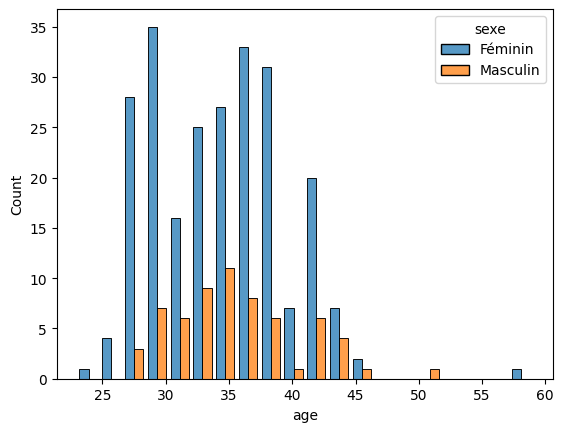

In [514]:
### AGE ### 
display(data['age'].describe())

sns.histplot(data=data, x="age", hue="sexe", multiple="dodge", shrink=.8, bins=20)

### SEXE ###

count         300
unique          2
top       Féminin
freq          237
Name: sexe, dtype: object

,proportions,valeurs
sexe,,
Féminin,79.0,237
Masculin,21.0,63


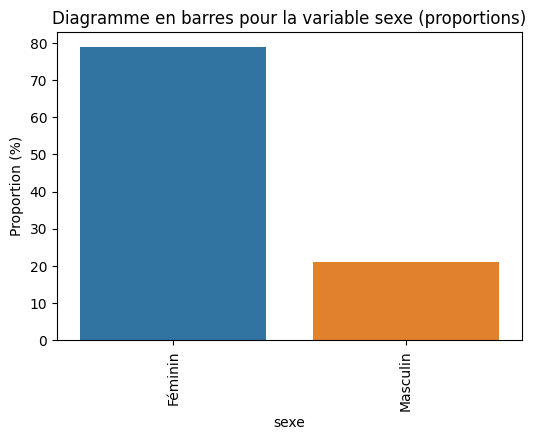

In [515]:
for col in ["sexe"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### DEPARTEMENT ### 

count     300
unique     60
top        78
freq       61
Name: departement, dtype: object

,proportions,valeurs
departement,,
78,20.333333,61
92,15.000000,45
38,12.000000,36
37,3.666667,11
56,3.333333,10
60,3.000000,9
44,2.000000,6
69,2.000000,6
94,2.000000,6


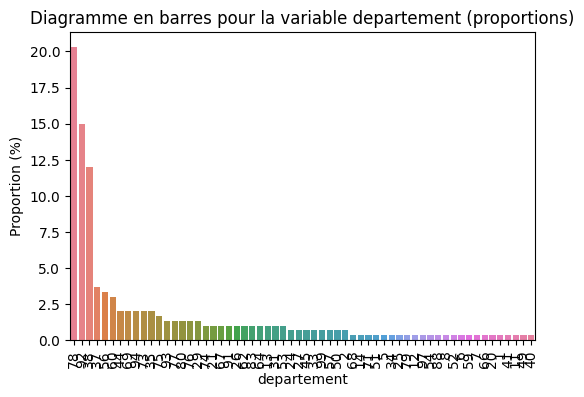

count     300
unique     60
top        78
freq       61
Name: departement, dtype: object

,proportions,valeurs
departement,,
Autre,32.666667,98
78,20.333333,61
92,15.000000,45
38,12.000000,36
37,3.666667,11
56,3.333333,10
60,3.000000,9
44,2.000000,6
73,2.000000,6


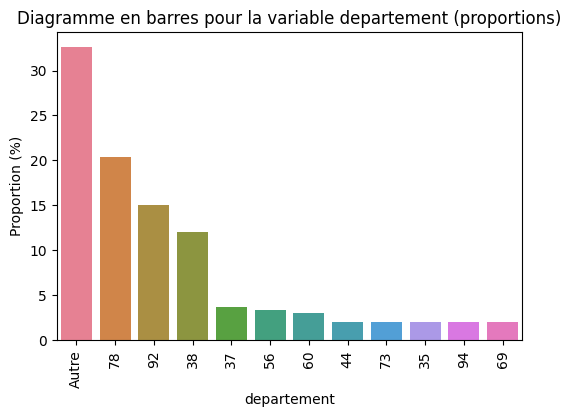

In [516]:
for col in ["departement"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

for col in ["departement"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))

    proportions = data[col].value_counts(normalize=True)
    small_categories = proportions[proportions < 0.02].index
    data_grouped = data[col].replace(small_categories, "Autre")

    proportions = data_grouped.value_counts(normalize=True) * 100
    values = data_grouped.value_counts()

    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### NIVEAU D'ETUDE ###

count           300
unique            3
top       ≥ Bac + 3
freq            259
Name: etudes, dtype: object

,proportions,valeurs
etudes,,
≥ Bac + 3,86.333333,259
Baccalauréat - Bac +2,10.333333,31
Inférieur au baccalauréat,3.333333,10


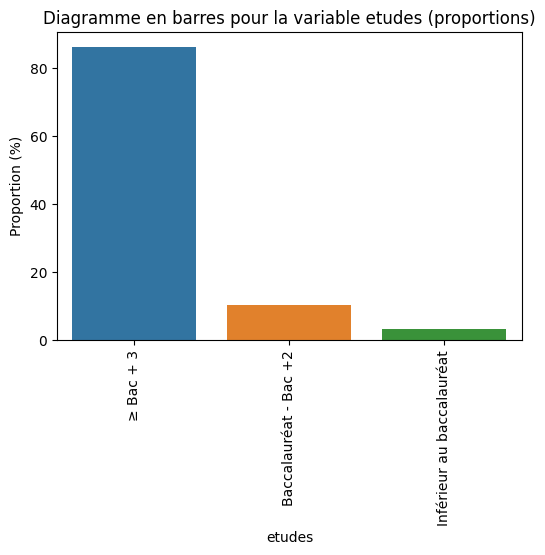

In [517]:
for col in ["etudes"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### SOCIAL

count    300.000000
mean       6.780000
std        1.340743
min        2.000000
25%        6.000000
50%        7.000000
75%        8.000000
max       10.000000
Name: social, dtype: float64

,proportions,valeurs
social,,
7,35.000000,105
8,22.333333,67
6,19.000000,57
5,12.333333,37
9,4.666667,14
4,3.000000,9
10,2.000000,6
3,1.333333,4
2,0.333333,1


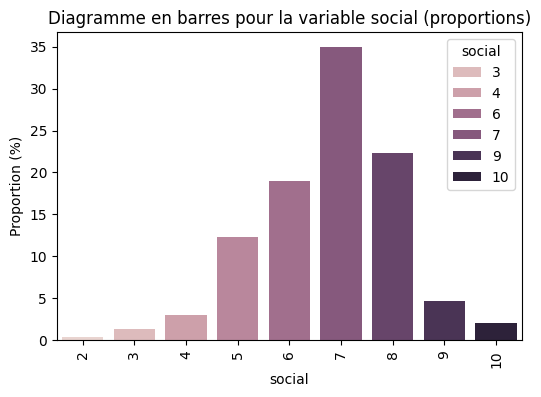

In [518]:
for col in ["social"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### EVOQUENT BRULURE SPONTANEMENT ###

count    300.000000
mean       0.623333
std        0.485360
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: brulure_spontane, dtype: float64

,proportions,valeurs
brulure_spontane,,
1,62.333333,187
0,37.666667,113


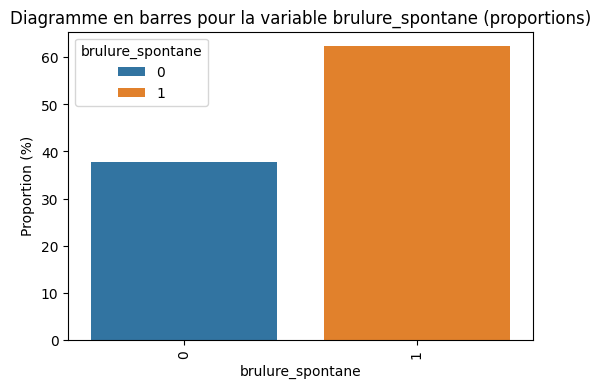

In [519]:
for col in ["brulure_spontane"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### ENFANTS DE PLUS DE 4 ANS ###

count    300.000000
mean       0.410000
std        0.492655
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: avec_enfant_plus_4_ans, dtype: float64

,proportions,valeurs
avec_enfant_plus_4_ans,,
0,59.0,177
1,41.0,123


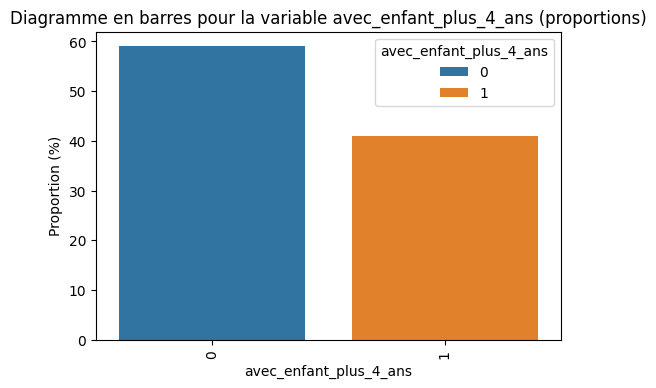

In [520]:
for col in ["avec_enfant_plus_4_ans"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### FINANCES ###

count     300
unique      2
top       Non
freq      268
Name: finances, dtype: object

,proportions,valeurs
finances,,
Non,89.333333,268
Oui,10.666667,32


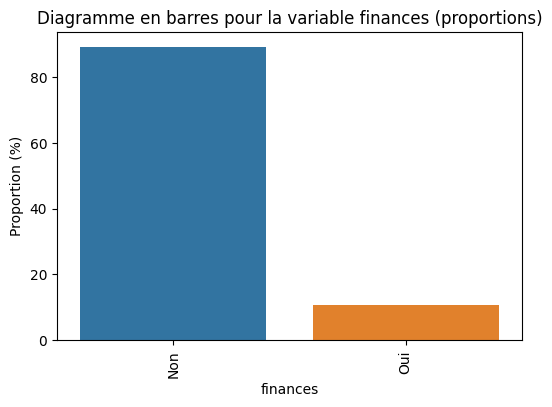

In [521]:
### FINANCES ### 
for col in ["finances"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### TABAC ###

count     300
unique      2
top       Non
freq      273
Name: tabac, dtype: object

,proportions,valeurs
tabac,,
Non,91.0,273
Oui,9.0,27


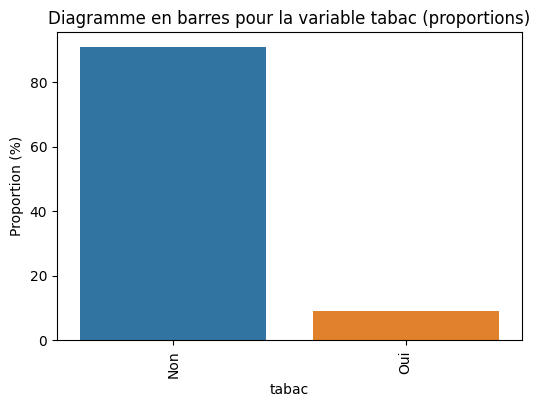

In [522]:
for col in ["tabac"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### ATCD ###

count     300
unique      2
top       Non
freq      253
Name: ATCD, dtype: object

,proportions,valeurs
ATCD,,
Non,84.333333,253
Oui,15.666667,47


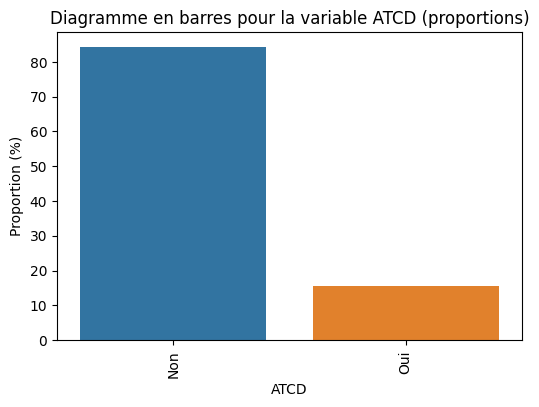

In [523]:
for col in ["ATCD"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### FORMATION SANTE ###

count     300
unique      2
top       Non
freq      192
Name: formation_sante, dtype: object

,proportions,valeurs
formation_sante,,
Non,64.0,192
Oui,36.0,108


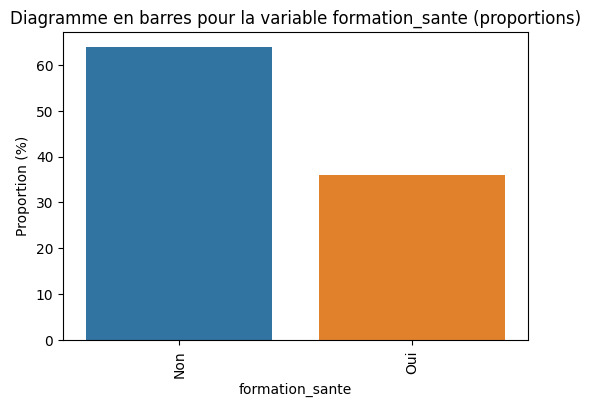

In [524]:
for col in ["formation_sante"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### TRAVAIL PETITE ENFANCE ###

count     300
unique      2
top       Non
freq      267
Name: travail_enfance, dtype: object

,proportions,valeurs
travail_enfance,,
Non,89.0,267
Oui,11.0,33


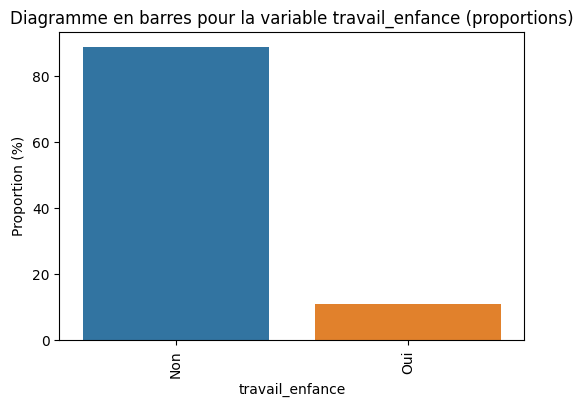

In [525]:
for col in ["travail_enfance"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### NOMBRE D'ENFANTS ###

count    300.000000
mean       2.300000
std        1.403531
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        8.000000
Name: nb_enfants, dtype: float64

,proportions,valeurs
nb_enfants,,
2,36.666667,110
1,31.666667,95
3,16.333333,49
4,8.000000,24
5,3.000000,9
6,2.333333,7
8,1.000000,3
7,1.000000,3


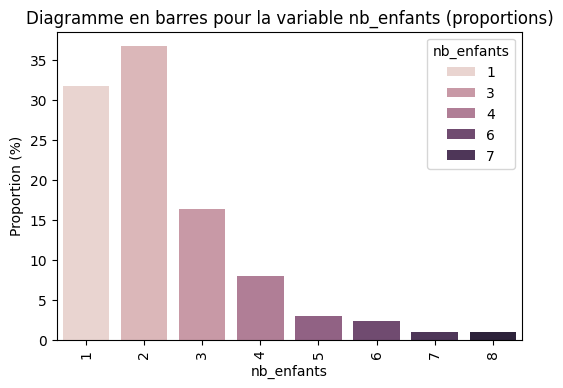

In [526]:
for col in ["nb_enfants"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### RESSOURCE SOIGNANTS ###

In [527]:
cols = ["ressource_mg", "ressource_ped", "ressource_pmi", "ressource_urg"]

# conversion oui / non => 1 / 0 
tmp = (
    data[cols].replace({"Oui": 1, "Non": 0})
)

tmp["ressource_autre"] = (
    data["ressource_autre"]
    .fillna("")
    .str.strip()
    .ne("")
    .astype(int)
)

freq = tmp.sum()

pct = (freq / len(tmp) * 100).round(1)

df_freq = pd.DataFrame({
    "effectif": freq.astype(int),
    "pourcentage": pct
})

display(df_freq.sort_values("pourcentage", ascending=False))

# Idées : comparaisons entre groupe (âge, niveau social, nombre d'enfants, etc)
# recherche des co-occurences 
# nombre moyen de réponses cochées 

tmp['nb_reponses'] = tmp.sum(axis=1)

df_nb_rep = (
    tmp['nb_reponses']
    .value_counts()
    .sort_index()
    .rename_axis("Nombre_de_reponses")
    .reset_index(name="effectif")
)

df_nb_rep["pourcentage"] = (
    df_nb_rep["effectif"] / len(tmp) * 100
).round(1)

display(df_nb_rep)


/var/folders/p9/3j1vdwh52f7620pmfxc9l1y00000gn/T/ipykernel_71170/2809612090.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols].replace({"Oui": 1, "Non": 0})


,effectif,pourcentage
ressource_mg,184,61.3
ressource_ped,137,45.7
ressource_pmi,11,3.7
ressource_urg,11,3.7
ressource_autre,8,2.7


,Nombre_de_reponses,effectif,pourcentage
0,1,256,85.3
1,2,37,12.3
2,3,7,2.3


### ATCD DE BRULURE ###

count     300
unique      2
top       Non
freq      279
Name: ATCD_brulure, dtype: object

,proportions,valeurs
ATCD_brulure,,
Non,93.0,279
Oui,7.0,21


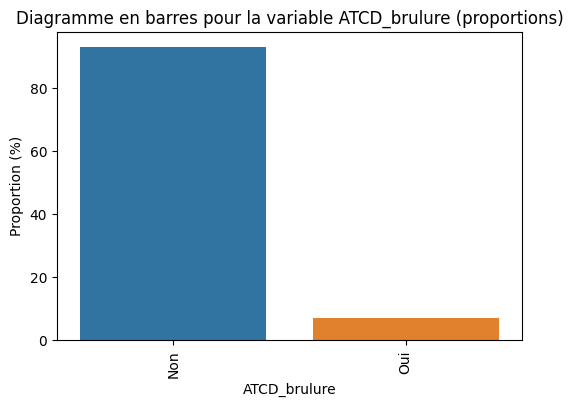

In [528]:
for col in ["ATCD_brulure"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### NIVEAU D'INFORMATION ###

count    300.000000
mean       3.333333
std        1.291426
min        0.000000
25%        3.000000
50%        4.000000
75%        4.000000
max        5.000000
Name: niveau_information, dtype: float64

,proportions,valeurs
niveau_information,,
4,31.000000,93
3,26.333333,79
5,19.333333,58
2,13.666667,41
1,6.333333,19
0,3.333333,10


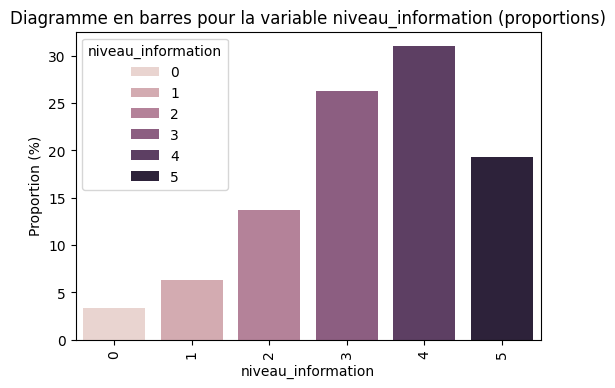

In [529]:
for col in ["niveau_information"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### SOURCE D'INFORMATION ###

In [530]:
cols = ["info_carnet", "info_brochure", "info_med", "info_formation", "info_perinat", "info_mater", "info_pmi"]

# conversion oui / non => 1 / 0 
tmp = (
    data[cols].replace({"Oui": 1, "Non": 0})
)

tmp["info_autre"] = (
    data["info_autre"]
    .fillna("")
    .str.strip()
    .ne("")
    .astype(int)
)

freq = tmp.sum()

pct = (freq / len(tmp) * 100).round(1)

df_freq = pd.DataFrame({
    "effectif": freq.astype(int),
    "pourcentage": pct
})

display(df_freq.sort_values("pourcentage", ascending=False))

# Idées : comparaisons entre groupe (âge, niveau social, nombre d'enfants, etc)
# recherche des co-occurences 
# nombre moyen de réponses cochées 

tmp['nb_reponses'] = tmp.sum(axis=1)

df_nb_rep = (
    tmp['nb_reponses']
    .value_counts()
    .sort_index()
    .rename_axis("Nombre_de_reponses")
    .reset_index(name="effectif")
)

df_nb_rep["pourcentage"] = (
    df_nb_rep["effectif"] / len(tmp) * 100
).round(1)

display(df_nb_rep)

/var/folders/p9/3j1vdwh52f7620pmfxc9l1y00000gn/T/ipykernel_71170/3116732686.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols].replace({"Oui": 1, "Non": 0})


,effectif,pourcentage
info_formation,173,57.7
info_carnet,118,39.3
info_autre,98,32.7
info_med,67,22.3
info_pmi,9,3.0
info_brochure,8,2.7
info_perinat,4,1.3
info_mater,2,0.7


,Nombre_de_reponses,effectif,pourcentage
0,1,167,55.7
1,2,99,33.0
2,3,24,8.0
3,4,9,3.0
4,6,1,0.3


## CONNAISSANCES

### TYPES DE BRULURE LES PLUS FREQUENTES ? ###

count           300
unique            5
top       Thermique
freq            236
Name: type_brulure, dtype: object

,proportions,valeurs
type_brulure,,
Thermique,78.666667,236
Par rayonnement d'une grande source de chaleur,9.333333,28
Par frottement,5.000000,15
Chimique,4.666667,14
Electrique,2.333333,7


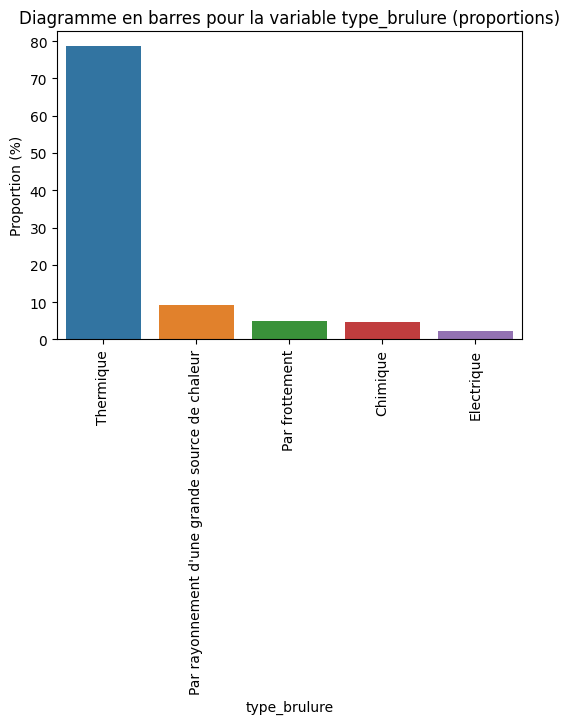

In [531]:
for col in ["type_brulure"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### BRULURES THERMIQUES LES PLUS FREQUENTES ? ###

count               300
unique                3
top       Liquide chaud
freq                265
Name: freq_thermique, dtype: object

,proportions,valeurs
freq_thermique,,
Liquide chaud,88.333333,265
Solide chaud,6.000000,18
Flamme/feu,5.666667,17


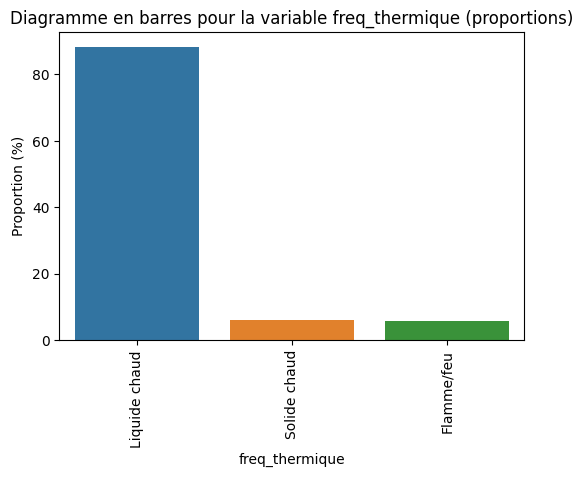

In [532]:
for col in ["freq_thermique"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### FREQUENCE LIQUIDE ALIMENTAIRE PARMI BRULURES THERMIQUES ###

count             300
unique              3
top       Plus de 60%
freq              187
Name: freq_liquide_alimentaire, dtype: object

,proportions,valeurs
freq_liquide_alimentaire,,
Plus de 60%,62.333333,187
Environ 40%,32.666667,98
Moins de 10%,5.000000,15


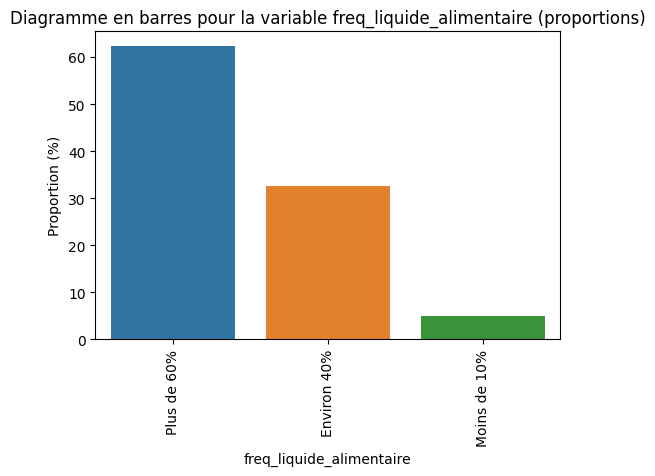

In [533]:
for col in ["freq_liquide_alimentaire"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### INTENTIONNALITE BRULURES ###

count               300
unique                3
top       Accidentelles
freq                297
Name: cause_brulure, dtype: object

,proportions,valeurs
cause_brulure,,
Accidentelles,99.000000,297
Liées à de la maltraitance,0.666667,2
Autre,0.333333,1


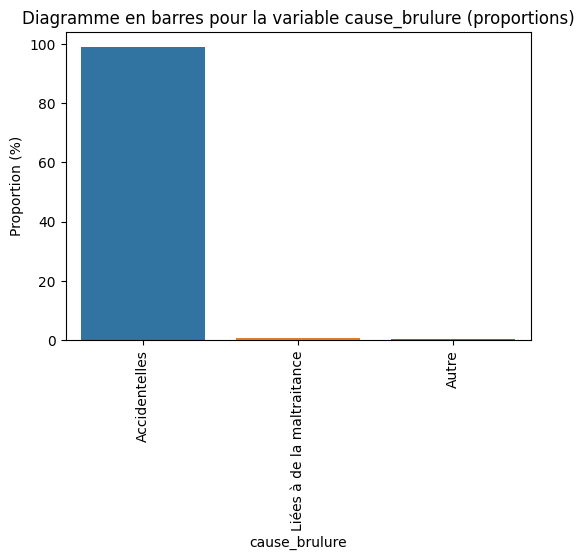

In [534]:
for col in ["cause_brulure"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### TRANCHE D'AGE NECESSITANT UNE HOSPITALISATION ET GRAVITE ### 

count             292
unique              3
top       Les 0-4 ans
freq              235
Name: freq_age_hospit, dtype: object

,proportions,valeurs
freq_age_hospit,,
Les 0-4 ans,80.479452,235
Les 5-14 ans,18.835616,55
Les 15-24 ans,0.684932,2


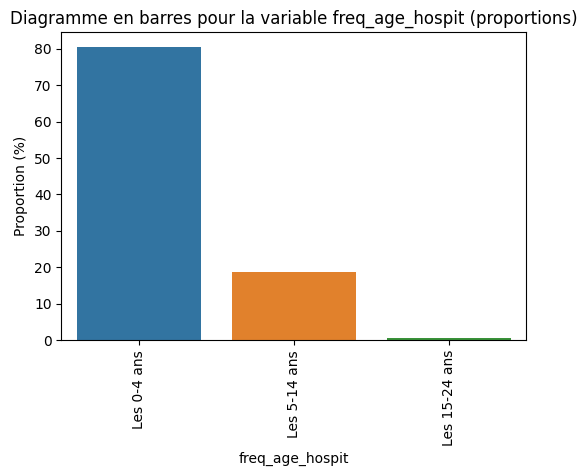

count             281
unique              3
top       Les 0-4 ans
freq              249
Name: gravite_hospit, dtype: object

,proportions,valeurs
gravite_hospit,,
Les 0-4 ans,88.612100,249
Les 5-14 ans,8.185053,23
Les 15-24 ans,3.202847,9


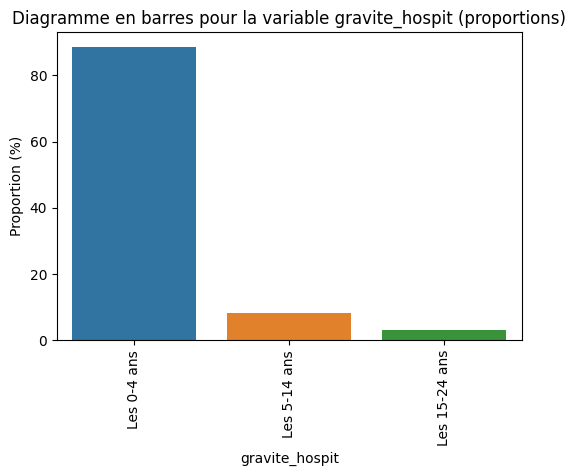

In [535]:
for col in ["freq_age_hospit", "gravite_hospit"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

In [536]:
### Plus grave = 15-24 ans. 

### SEXE ET HOSPITALISATION ###

count                                                   300
unique                                                    3
top       Autant chez les filles/femmes que les garçons/...
freq                                                    220
Name: freq_sexe, dtype: object

,proportions,valeurs
freq_sexe,,
Autant chez les filles/femmes que les garçons/hommes,73.333333,220
Chez les garçons/hommes,21.333333,64
Chez les filles/femmes,5.333333,16


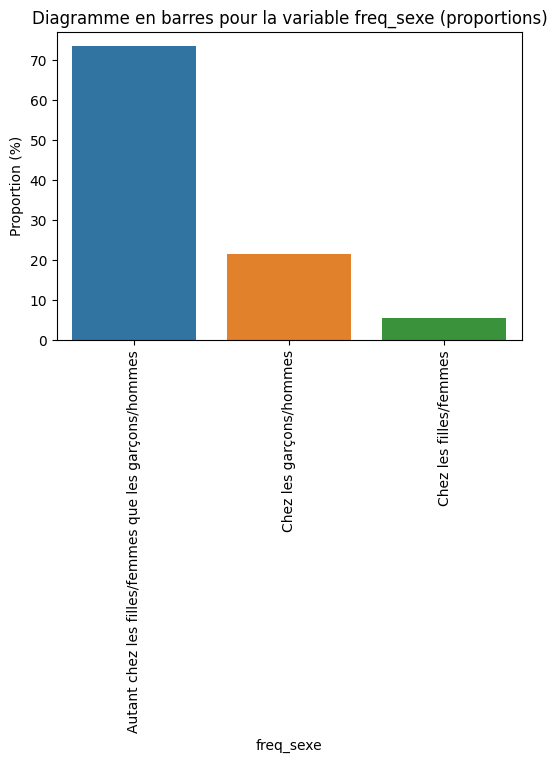

In [537]:
for col in ["freq_sexe"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

In [538]:
# Garçons plus à risque. 

### PIECE LA PLUS A RISQUE DE BRULURE ###

count            300
unique             5
top       La cuisine
freq             284
Name: piece_risque, dtype: object

,proportions,valeurs
piece_risque,,
La cuisine,94.666667,284
La salle de bain,2.333333,7
Le salon,1.666667,5
Autre,1.000000,3
La buanderie,0.333333,1


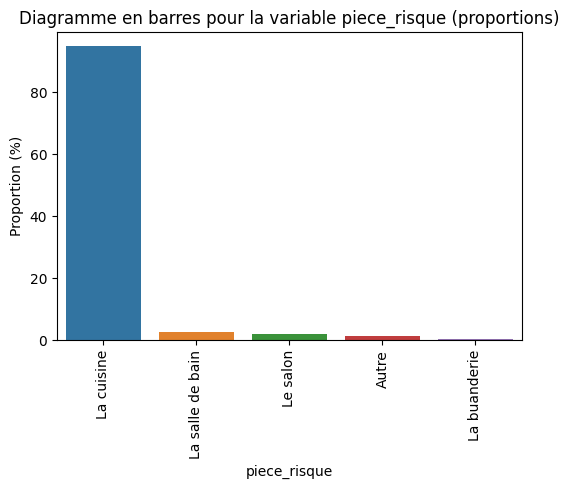

In [539]:
for col in ["piece_risque"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### BRULURE EN 3S AVEC EAU A 60 DEG ? ###

count                              289
unique                               3
top       Oui, et la brûlure est grave
freq                               166
Name: brulure_3s, dtype: object

,proportions,valeurs
brulure_3s,,
"Oui, et la brûlure est grave",57.439446,166
"Oui, et la brûlure est superficielle",42.214533,122
"Non, l'eau à 60°C ne brûle pas",0.346021,1


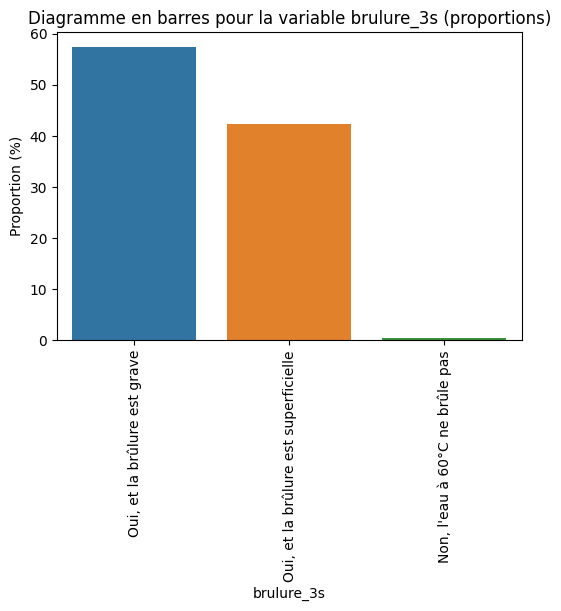

In [540]:
for col in ["brulure_3s"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### TEMPERATURE DU BAIN ###

count      297
unique       4
top       37°C
freq       256
Name: temperature_bain, dtype: object

,proportions,valeurs
temperature_bain,,
37°C,86.195286,256
35°C,8.417508,25
33°C,3.030303,9
39°C,2.356902,7


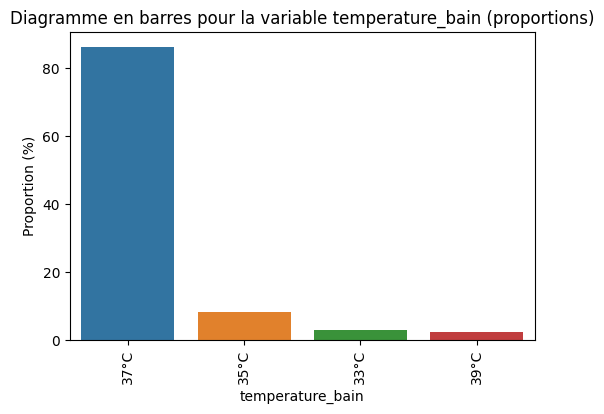

In [541]:
for col in ["temperature_bain"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### CIRCONSTANCES A RISQUE ###

In [542]:
cols = [
    "risque_brulure_bain", 
    "risque_brulure_chaise", 
    "risque_brulure_prod_entretien", 
    "risque_brulure_cuisiniere", 
    "risque_brulure_table_langer", 
    "risque_brulure_nappe"
]

bad_answers = [
    "risque_brulure_chaise",
    "risque_brulure_table_langer"
]

display(data)

# conversion oui / non => 1 / 0 
data[cols] = (
    data[cols].replace({"Oui": 1, "Non": 0})
)

data[bad_answers] = 1 - data[bad_answers]

data["risque_brulure_circonstance"] = data[cols].sum(axis=1) / 6

display(data)

tmp = data[cols]

freq = tmp.sum()

pct = (freq / len(tmp) * 100).round(1)

df_freq = pd.DataFrame({
    "effectif": freq.astype(int),
    "pourcentage": pct
})

display(df_freq.sort_values("pourcentage", ascending=False))

# Idées : comparaisons entre groupe (âge, niveau social, nombre d'enfants, etc)
# recherche des co-occurences 

tmp['nb_reponses'] = tmp.sum(axis=1)

df_nb_rep = (
    tmp['nb_reponses']
    .value_counts()
    .sort_index()
    .rename_axis("Nombre_de_reponses")
    .reset_index(name="effectif")
)

df_nb_rep["pourcentage"] = (
    df_nb_rep["effectif"] / len(tmp) * 100
).round(1)

display(df_nb_rep)

,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,Durée_pour_le_groupe_:_Cas_cliniques,Durée_pour_la_question:_reaction,Durée_pour_la_question:_cas1,Durée_pour_la_question:_cas2,Durée_pour_la_question:_cas3,Durée_pour_la_question:_cas4,Durée_pour_le_groupe_:_En_apprendre_d'avantage...,Durée_pour_la_question:_ensavoirplus,avec_enfant_plus_4_ans,brulure_spontane
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,201.94,NaN,NaN,NaN,NaN,NaN,5.76,NaN,0,0
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,160.07,NaN,NaN,NaN,NaN,NaN,6.82,NaN,0,0
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,254.48,NaN,NaN,NaN,NaN,NaN,11.75,NaN,1,0
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,3330.84,NaN,NaN,NaN,NaN,NaN,28.39,NaN,1,1
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,204.54,NaN,NaN,NaN,NaN,NaN,6.63,NaN,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,106.00,NaN,NaN,NaN,NaN,NaN,5.09,NaN,1,0
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,131.61,NaN,NaN,NaN,NaN,NaN,7.43,NaN,0,0
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,140.11,NaN,NaN,NaN,NaN,NaN,7.72,NaN,0,1
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,180.27,NaN,NaN,NaN,NaN,NaN,6.53,NaN,0,0


/var/folders/p9/3j1vdwh52f7620pmfxc9l1y00000gn/T/ipykernel_71170/4013705762.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols].replace({"Oui": 1, "Non": 0})


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,Durée_pour_la_question:_reaction,Durée_pour_la_question:_cas1,Durée_pour_la_question:_cas2,Durée_pour_la_question:_cas3,Durée_pour_la_question:_cas4,Durée_pour_le_groupe_:_En_apprendre_d'avantage...,Durée_pour_la_question:_ensavoirplus,avec_enfant_plus_4_ans,brulure_spontane,risque_brulure_circonstance
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,NaN,NaN,NaN,NaN,NaN,5.76,NaN,0,0,1.000000
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,NaN,NaN,NaN,NaN,NaN,6.82,NaN,0,0,0.833333
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,NaN,NaN,NaN,NaN,NaN,11.75,NaN,1,0,1.000000
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,NaN,NaN,NaN,NaN,NaN,28.39,NaN,1,1,0.666667
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,NaN,NaN,NaN,NaN,NaN,6.63,NaN,1,1,0.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,NaN,NaN,NaN,NaN,NaN,5.09,NaN,1,0,0.500000
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,NaN,NaN,NaN,NaN,NaN,7.43,NaN,0,0,0.500000
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,NaN,NaN,NaN,NaN,NaN,7.72,NaN,0,1,0.833333
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,NaN,NaN,NaN,NaN,NaN,6.53,NaN,0,0,1.000000


,effectif,pourcentage
risque_brulure_cuisiniere,287,95.7
risque_brulure_table_langer,277,92.3
risque_brulure_chaise,251,83.7
risque_brulure_prod_entretien,246,82.0
risque_brulure_nappe,246,82.0
risque_brulure_bain,136,45.3


/var/folders/p9/3j1vdwh52f7620pmfxc9l1y00000gn/T/ipykernel_71170/4013705762.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['nb_reponses'] = tmp.sum(axis=1)


,Nombre_de_reponses,effectif,pourcentage
0,1,1,0.3
1,2,2,0.7
2,3,30,10.0
3,4,53,17.7
4,5,148,49.3
5,6,66,22.0


### EVALUATION DE LA TEMPERATURE DU BIBERON ###

count                                    298
unique                                     6
top       Le poignet (côté paume de la main)
freq                                     189
Name: evaluation_temp_bib, dtype: object

,proportions,valeurs
evaluation_temp_bib,,
Le poignet (côté paume de la main),63.422819,189
Le dos de la main,16.107383,48
La bouche,8.053691,24
Le coude,5.033557,15
Le poignet (côté dos de la main),4.362416,13
La paume de la main,3.020134,9


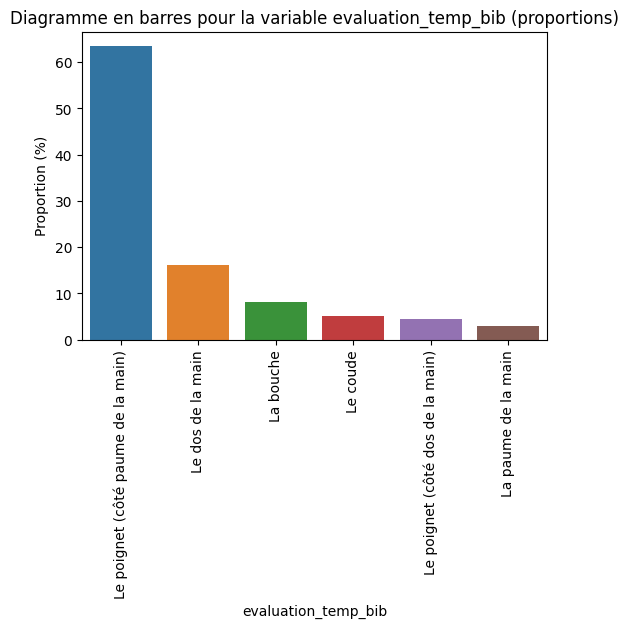

In [543]:
for col in ["evaluation_temp_bib"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### SCORE DE CONNAISSANCE

,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c3,c4,c5,c6,c7,c8,c9,c10,c11,score_connaissance
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,1,1,1,0,1,1,0,1,10.000000
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,0,1,1,0,0,1,1,1,0,7.833333
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,1,1,1,0,0,1,0,1,0,8.000000
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,1,1,1,0,0,1,0,1,1,8.666667
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,1,1,0,0,0,1,1,1,1,8.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,1,0,0,0,1,0,0,1,4.500000
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,0,1,0,0,0,1,1,1,0,4.500000
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,1,1,1,0,0,1,0,0,1,7.833333
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,1,1,0,0,0,0,1,1,1,7.000000


count    300.000000
mean       8.095000
std        1.351793
min        3.833333
25%        7.500000
50%        8.000000
75%        8.833333
max       11.000000
Name: score_connaissance, dtype: float64

,proportions,valeurs
score_connaissance,,
7.833333,15.333333,46
8.833333,14.666667,44
6.833333,7.333333,22
8.000000,7.000000,21
9.833333,6.333333,19
9.000000,5.666667,17
10.000000,4.666667,14
9.666667,4.333333,13
8.666667,4.000000,12


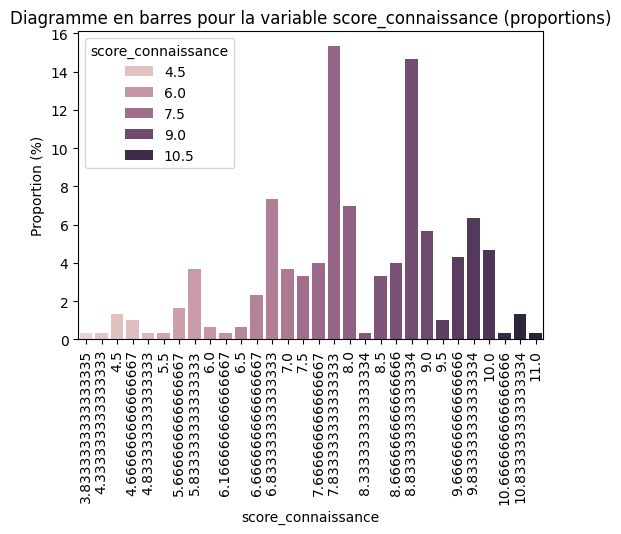

In [544]:
data['c1'] = 0
data.loc[data['type_brulure'] == 'Thermique', "c1"] = 1

data['c2'] = 0
data.loc[data['freq_thermique'] == 'Liquide chaud', "c2"] = 1

data['c3'] = 0
data.loc[data['freq_liquide_alimentaire'] == 'Plus de 60%', "c3"] = 1

data['c4'] = 0
data.loc[data['cause_brulure'] == 'Accidentelles', "c4"] = 1

data['c5'] = 0
data.loc[data['freq_age_hospit'] == 'Les 0-4 ans', "c5"] = 1

data['c6'] = 0
data.loc[data['gravite_hospit'] == 'Les 15-24 ans', "c6"] = 1

data['c7'] = 0
data.loc[data['freq_sexe'] == 'Chez les garçons/hommes', "c7"] = 1

data['c8'] = 0
data.loc[data['piece_risque'] == 'La cuisine', "c8"] = 1

data['c9'] = 0
data.loc[data['brulure_3s'] == 'Oui, et la brûlure est grave', "c9"] = 1

data['c10'] = 0
data.loc[data['temperature_bain'] == '37°C', "c10"] = 1

data['c11'] = 0
data.loc[data['evaluation_temp_bib'] == 'Le poignet (côté paume de la main)', "c11"] = 1

connaissances = ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10', 'c11', 'risque_brulure_circonstance']

data['score_connaissance'] = data[connaissances].sum(axis=1)

display(data)

for col in ["score_connaissance"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

Score de connaissance sur 12. 

### MOYENS DE PREVENTION ###

In [545]:
cols = [
    "prevention_eau_bain", 
    "prevention_robinets", 
    "prevention_presence_bain", 
    "prevention_acces_cuisine", 
    "prevention_manches", 
    "prevention_four", 
    "prevention_temp_aliments",
    "prevention_biberon_microonde",
    "prevention_agitation_bib",
    "prevention_fer_repasser",
    "prevention_boisson_chaude",
    "prevention_allumettes",
    "prevention_tabac",
    "prevention_bbq",
    "prevention_alcool",
    "prevention_normes",
    "previention_prises",
    "prevention_soleil",
    "prevention_soleil_2",
    "prevention_aucun"
]

# conversion oui / non => 1 / 0 
data[cols] = (
    data[cols].replace({"Oui": 1, "Non": 0})
)

data["prevention_autre"] = (
    data["prevention_autre"]
    .fillna("")
    .str.strip()
    .ne("")
    .astype(int)
)

cols.append("prevention_autre")

tmp = data[cols]
display(tmp)

freq = tmp.sum()

pct = (freq / len(tmp) * 100).round(1)

df_freq = pd.DataFrame({
    "effectif": freq.astype(int),
    "pourcentage": pct
})

cols.remove("prevention_aucun")
data['nb_moyen_prevention'] = data[cols].sum(axis=1) 

display(data)

display(df_freq.sort_values("pourcentage", ascending=False))

# Idées : comparaisons entre groupe (âge, niveau social, nombre d'enfants, etc)
# recherche des co-occurences 
# nombre moyen de réponses cochées 

tmp['nb_reponses'] = tmp.sum(axis=1)

df_nb_rep = (
    tmp['nb_reponses']
    .value_counts()
    .sort_index()
    .rename_axis("Nombre_de_reponses")
    .reset_index(name="effectif")
)

df_nb_rep["pourcentage"] = (
    df_nb_rep["effectif"] / len(tmp) * 100
).round(1)

display(df_nb_rep)

/var/folders/p9/3j1vdwh52f7620pmfxc9l1y00000gn/T/ipykernel_71170/2336044025.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols].replace({"Oui": 1, "Non": 0})


,prevention_eau_bain,prevention_robinets,prevention_presence_bain,prevention_acces_cuisine,prevention_manches,prevention_four,prevention_temp_aliments,prevention_biberon_microonde,prevention_agitation_bib,prevention_fer_repasser,...,prevention_allumettes,prevention_tabac,prevention_bbq,prevention_alcool,prevention_normes,previention_prises,prevention_soleil,prevention_soleil_2,prevention_aucun,prevention_autre
1,1,0,1,0,1,1,1,0,0,0,...,1,1,1,1,0,0,1,1,0,0
2,1,0,1,0,1,1,1,0,1,1,...,1,1,1,1,1,0,1,0,0,0
4,1,0,1,1,1,1,1,0,1,0,...,1,0,1,1,1,0,1,0,0,0
5,1,0,1,0,1,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0
7,1,0,1,0,1,1,1,0,1,0,...,1,0,0,1,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,1,1,1,1,1,0,1,0,1,0,...,1,0,1,1,1,0,1,1,0,0
554,1,0,1,1,1,1,1,1,1,0,...,1,1,1,1,1,1,1,1,0,0
555,1,0,1,0,1,0,1,1,0,1,...,1,1,0,1,0,1,1,1,0,0
556,1,0,1,0,1,1,1,1,0,1,...,1,1,1,1,0,1,1,1,0,0


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c4,c5,c6,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,1,1,0,1,1,0,1,10.000000,12
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,1,1,0,0,1,1,1,0,7.833333,14
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,1,1,0,0,1,0,1,0,8.000000,13
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,1,1,0,0,1,0,1,1,8.666667,7
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,1,0,0,0,1,1,1,1,8.833333,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,1,0,0,0,1,0,0,1,4.500000,13
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,1,0,0,0,1,1,1,0,4.500000,16
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,1,1,0,0,1,0,0,1,7.833333,13
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,1,0,0,0,0,1,1,1,7.000000,14


,effectif,pourcentage
prevention_eau_bain,277,92.3
prevention_temp_aliments,268,89.3
prevention_manches,267,89.0
prevention_presence_bain,261,87.0
prevention_soleil,256,85.3
prevention_soleil_2,247,82.3
prevention_allumettes,246,82.0
prevention_bbq,228,76.0
prevention_agitation_bib,226,75.3
prevention_normes,218,72.7


/var/folders/p9/3j1vdwh52f7620pmfxc9l1y00000gn/T/ipykernel_71170/2336044025.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['nb_reponses'] = tmp.sum(axis=1)


,Nombre_de_reponses,effectif,pourcentage
0,2,1,0.3
1,3,4,1.3
2,4,4,1.3
3,5,1,0.3
4,6,7,2.3
5,7,10,3.3
6,8,13,4.3
7,9,24,8.0
8,10,21,7.0
9,11,21,7.0


### AUTO-EVALUATION CAPACITES DE REACTION ###

count    300.000000
mean       3.423333
std        1.000396
min        0.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: auto_evaluation_reaction, dtype: float64

,proportions,valeurs
auto_evaluation_reaction,,
3,38.666667,116
4,32.333333,97
5,14.333333,43
2,11.333333,34
1,2.666667,8
0,0.666667,2


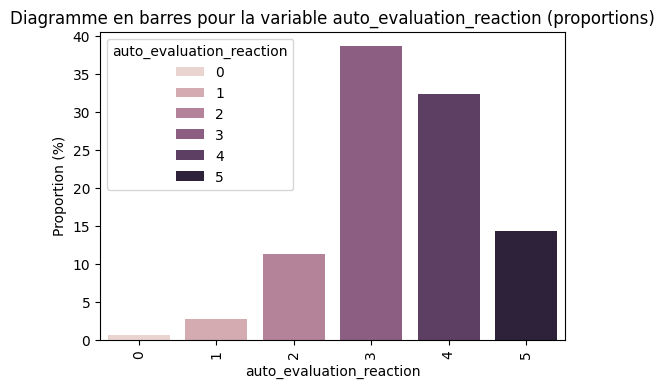

In [546]:
for col in ["auto_evaluation_reaction"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### CAS CLINIQUE 1 ###

In [547]:
# Réponses correctes : 2 / 4 / 5 / 7 


In [548]:
cols = [
    "cc1_rep1", 
    "cc1_rep2", 
    "cc1_rep3", 
    "cc1_rep4", 
    "cc1_rep5", 
    "cc1_rep6", 
    "cc1_rep7"
]

bad_answers = [
    "cc1_rep1",
    "cc1_rep3",
    "cc1_rep6"
]

# conversion oui / non => 1 / 0 
data[cols] = (
    data[cols].replace({"Oui": 1, "Non": 0})
)

display(data)

data[bad_answers] = 1 - data[bad_answers]

display(data)

tmp = data[cols]

freq = tmp.sum()

pct = (freq / len(tmp) * 100).round(1)

df_freq = pd.DataFrame({
    "effectif": freq.astype(int),
    "proportion de réponses justes": pct
})

display(df_freq)

# display(df_freq.sort_values("pourcentage juste", ascending=False))

# Idées : comparaisons entre groupe (âge, niveau social, nombre d'enfants, etc)
# recherche des co-occurences 
# nombre moyen de réponses cochées 

# tmp['nb_reponses'] = tmp.sum(axis=1)

# df_nb_rep = (
#     tmp['nb_reponses']
#     .value_counts()
#     .sort_index()
#     .rename_axis("Nombre_de_reponses")
#     .reset_index(name="effectif")
# )

# df_nb_rep["pourcentage"] = (
#     df_nb_rep["effectif"] / len(tmp) * 100
# ).round(1)

# display(df_nb_rep)

/var/folders/p9/3j1vdwh52f7620pmfxc9l1y00000gn/T/ipykernel_71170/1555485685.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols].replace({"Oui": 1, "Non": 0})


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c4,c5,c6,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,1,1,0,1,1,0,1,10.000000,12
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,1,1,0,0,1,1,1,0,7.833333,14
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,1,1,0,0,1,0,1,0,8.000000,13
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,1,1,0,0,1,0,1,1,8.666667,7
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,1,0,0,0,1,1,1,1,8.833333,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,1,0,0,0,1,0,0,1,4.500000,13
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,1,0,0,0,1,1,1,0,4.500000,16
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,1,1,0,0,1,0,0,1,7.833333,13
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,1,0,0,0,0,1,1,1,7.000000,14


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c4,c5,c6,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,1,1,0,1,1,0,1,10.000000,12
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,1,1,0,0,1,1,1,0,7.833333,14
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,1,1,0,0,1,0,1,0,8.000000,13
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,1,1,0,0,1,0,1,1,8.666667,7
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,1,0,0,0,1,1,1,1,8.833333,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,1,0,0,0,1,0,0,1,4.500000,13
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,1,0,0,0,1,1,1,0,4.500000,16
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,1,1,0,0,1,0,0,1,7.833333,13
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,1,0,0,0,0,1,1,1,7.000000,14


,effectif,proportion de réponses justes
cc1_rep1,298,99.3
cc1_rep2,196,65.3
cc1_rep3,134,44.7
cc1_rep4,130,43.3
cc1_rep5,121,40.3
cc1_rep6,271,90.3
cc1_rep7,228,76.0


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c5,c6,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,1,0,1,1,0,1,10.000000,12,4
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,1,0,0,1,1,1,0,7.833333,14,4
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,1,0,0,1,0,1,0,8.000000,13,7
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,1,0,0,1,0,1,1,8.666667,7,2
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,0,0,0,1,1,1,1,8.833333,12,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,0,0,1,0,0,1,4.500000,13,3
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,0,0,0,1,1,1,0,4.500000,16,5
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,1,0,0,1,0,0,1,7.833333,13,6
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,0,0,0,0,1,1,1,7.000000,14,4


count    300.000000
mean       4.593333
std        1.280660
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        7.000000
Name: cc1_global, dtype: float64

,proportions,valeurs
cc1_global,,
5,28.666667,86
4,26.000000,78
6,17.666667,53
3,16.000000,48
7,7.000000,21
2,4.333333,13
1,0.333333,1


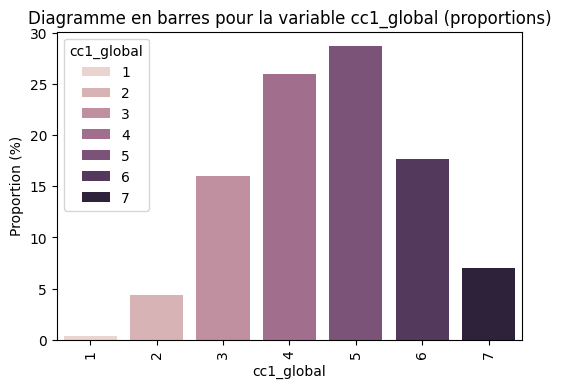

In [549]:
data['cc1_global'] = data[cols].sum(axis=1)
display(data)

for col in ["cc1_global"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### CAS CLINIQUE 2 ###

In [550]:
# Réponses justes : 1, 3, 7, 8 

In [551]:
cols = [
    "cc2_rep1", #
    "cc2_rep2", 
    "cc2_rep3", #
    "cc2_rep4", 
    "cc2_rep5", 
    "cc2_rep6", 
    "cc2_rep7", #
    "cc2_rep8"  #
]

bad_answers = [
    "cc2_rep2",
    "cc2_rep4", 
    "cc2_rep5",
    "cc2_rep6"
]

# conversion oui / non => 1 / 0 
data[cols] = (
    data[cols].replace({"Oui": 1, "Non": 0})
)

display(data)

data[bad_answers] = 1 - data[bad_answers]

display(data)

tmp = data[cols]

freq = tmp.sum()

pct = (freq / len(tmp) * 100).round(1)

df_freq = pd.DataFrame({
    "effectif": freq.astype(int),
    "proportion de réponses justes": pct
})

display(df_freq)

# display(df_freq.sort_values("pourcentage juste", ascending=False))

/var/folders/p9/3j1vdwh52f7620pmfxc9l1y00000gn/T/ipykernel_71170/1433447112.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols].replace({"Oui": 1, "Non": 0})


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c5,c6,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,1,0,1,1,0,1,10.000000,12,4
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,1,0,0,1,1,1,0,7.833333,14,4
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,1,0,0,1,0,1,0,8.000000,13,7
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,1,0,0,1,0,1,1,8.666667,7,2
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,0,0,0,1,1,1,1,8.833333,12,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,0,0,1,0,0,1,4.500000,13,3
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,0,0,0,1,1,1,0,4.500000,16,5
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,1,0,0,1,0,0,1,7.833333,13,6
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,0,0,0,0,1,1,1,7.000000,14,4


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c5,c6,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,1,0,1,1,0,1,10.000000,12,4
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,1,0,0,1,1,1,0,7.833333,14,4
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,1,0,0,1,0,1,0,8.000000,13,7
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,1,0,0,1,0,1,1,8.666667,7,2
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,0,0,0,1,1,1,1,8.833333,12,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,0,0,1,0,0,1,4.500000,13,3
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,0,0,0,1,1,1,0,4.500000,16,5
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,1,0,0,1,0,0,1,7.833333,13,6
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,0,0,0,0,1,1,1,7.000000,14,4


,effectif,proportion de réponses justes
cc2_rep1,202,67.3
cc2_rep2,217,72.3
cc2_rep3,207,69.0
cc2_rep4,296,98.7
cc2_rep5,298,99.3
cc2_rep6,252,84.0
cc2_rep7,149,49.7
cc2_rep8,245,81.7


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c6,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global,cc2_global
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,0,1,1,0,1,10.000000,12,4,6
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,0,0,1,1,1,0,7.833333,14,4,4
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,0,0,1,0,1,0,8.000000,13,7,7
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,0,0,1,0,1,1,8.666667,7,2,7
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,0,0,1,1,1,1,8.833333,12,5,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,0,1,0,0,1,4.500000,13,3,4
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,0,0,1,1,1,0,4.500000,16,5,5
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,0,0,1,0,0,1,7.833333,13,6,6
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,0,0,0,1,1,1,7.000000,14,4,6


count    300.000000
mean       6.220000
std        1.418323
min        2.000000
25%        5.000000
50%        6.000000
75%        7.000000
max        8.000000
Name: cc2_global, dtype: float64

,proportions,valeurs
cc2_global,,
7,28.666667,86
6,25.000000,75
8,19.333333,58
5,15.000000,45
4,8.000000,24
2,2.333333,7
3,1.666667,5


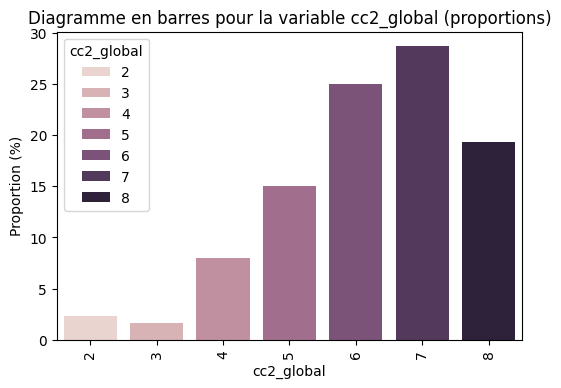

In [552]:
data['cc2_global'] = data[cols].sum(axis=1)
display(data)

for col in ["cc2_global"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### CAS CLINIQUE 3 ###

In [553]:
# Réponses justes : 5, 6 

In [554]:
cols = [
    "cc3_rep1", 
    "cc3_rep2", 
    "cc3_rep3", 
    "cc3_rep4", 
    "cc3_rep5", #
    "cc3_rep6"  #
]

bad_answers = [
    "cc3_rep1",
    "cc3_rep2", 
    "cc3_rep3",
    "cc3_rep4"
]

# conversion oui / non => 1 / 0 
data[cols] = (
    data[cols].replace({"Oui": 1, "Non": 0})
)

display(data)

data[bad_answers] = 1 - data[bad_answers]

display(data)

tmp = data[cols]

freq = tmp.sum()

pct = (freq / len(tmp) * 100).round(1)

df_freq = pd.DataFrame({
    "effectif": freq.astype(int),
    "proportion de réponses justes": pct
})

display(df_freq)

# display(df_freq.sort_values("pourcentage juste", ascending=False))

/var/folders/p9/3j1vdwh52f7620pmfxc9l1y00000gn/T/ipykernel_71170/510639937.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols].replace({"Oui": 1, "Non": 0})


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c6,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global,cc2_global
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,0,1,1,0,1,10.000000,12,4,6
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,0,0,1,1,1,0,7.833333,14,4,4
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,0,0,1,0,1,0,8.000000,13,7,7
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,0,0,1,0,1,1,8.666667,7,2,7
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,0,0,1,1,1,1,8.833333,12,5,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,0,1,0,0,1,4.500000,13,3,4
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,0,0,1,1,1,0,4.500000,16,5,5
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,0,0,1,0,0,1,7.833333,13,6,6
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,0,0,0,1,1,1,7.000000,14,4,6


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c6,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global,cc2_global
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,0,1,1,0,1,10.000000,12,4,6
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,0,0,1,1,1,0,7.833333,14,4,4
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,0,0,1,0,1,0,8.000000,13,7,7
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,0,0,1,0,1,1,8.666667,7,2,7
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,0,0,1,1,1,1,8.833333,12,5,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,0,1,0,0,1,4.500000,13,3,4
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,0,0,1,1,1,0,4.500000,16,5,5
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,0,0,1,0,0,1,7.833333,13,6,6
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,0,0,0,1,1,1,7.000000,14,4,6


,effectif,proportion de réponses justes
cc3_rep1,300,100.0
cc3_rep2,267,89.0
cc3_rep3,150,50.0
cc3_rep4,284,94.7
cc3_rep5,96,32.0
cc3_rep6,295,98.3


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global,cc2_global,cc3_global
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,0,1,1,0,1,10.000000,12,4,6,4
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,0,1,1,1,0,7.833333,14,4,4,5
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,0,1,0,1,0,8.000000,13,7,7,4
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,0,1,0,1,1,8.666667,7,2,7,6
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,0,1,1,1,1,8.833333,12,5,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,1,0,0,1,4.500000,13,3,4,5
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,0,1,1,1,0,4.500000,16,5,5,5
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,0,1,0,0,1,7.833333,13,6,6,4
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,0,0,1,1,1,7.000000,14,4,6,5


count    300.000000
mean       4.640000
std        0.824215
min        2.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        6.000000
Name: cc3_global, dtype: float64

,proportions,valeurs
cc3_global,,
5,41.333333,124
4,38.333333,115
6,14.666667,44
3,4.666667,14
2,1.000000,3


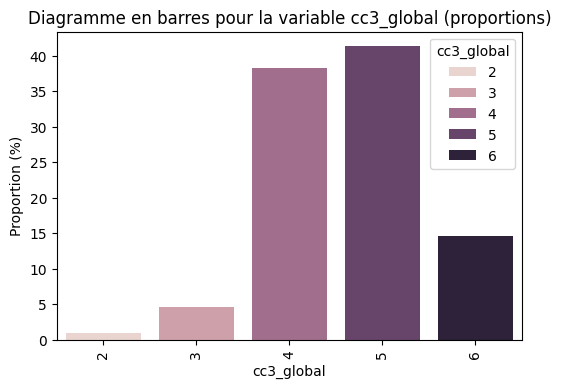

In [555]:
data['cc3_global'] = data[cols].sum(axis=1)
display(data)

for col in ["cc3_global"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### CAS CLINIQUE 4 ###

In [556]:
# Réponses justes : 2, 3, 4, 6, 7 

In [557]:
cols = [
    "cc4_rep1", 
    "cc4_rep2", #
    "cc4_rep3", #
    "cc4_rep4", #
    "cc4_rep5", 
    "cc4_rep6", #
    "cc4_rep7"  #
]

bad_answers = [
    "cc4_rep1",
    "cc4_rep5"
]

# conversion oui / non => 1 / 0 
data[cols] = (
    data[cols].replace({"Oui": 1, "Non": 0})
)

display(data)

data[bad_answers] = 1 - data[bad_answers]

display(data)

tmp = data[cols]

freq = tmp.sum()

pct = (freq / len(tmp) * 100).round(1)

df_freq = pd.DataFrame({
    "effectif": freq.astype(int),
    "proportion de réponses justes": pct
})

display(df_freq)

# display(df_freq.sort_values("pourcentage juste", ascending=False))

/var/folders/p9/3j1vdwh52f7620pmfxc9l1y00000gn/T/ipykernel_71170/1355811827.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols].replace({"Oui": 1, "Non": 0})


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global,cc2_global,cc3_global
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,0,1,1,0,1,10.000000,12,4,6,4
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,0,1,1,1,0,7.833333,14,4,4,5
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,0,1,0,1,0,8.000000,13,7,7,4
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,0,1,0,1,1,8.666667,7,2,7,6
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,0,1,1,1,1,8.833333,12,5,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,1,0,0,1,4.500000,13,3,4,5
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,0,1,1,1,0,4.500000,16,5,5,5
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,0,1,0,0,1,7.833333,13,6,6,4
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,0,0,1,1,1,7.000000,14,4,6,5


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c7,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global,cc2_global,cc3_global
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,0,1,1,0,1,10.000000,12,4,6,4
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,0,1,1,1,0,7.833333,14,4,4,5
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,0,1,0,1,0,8.000000,13,7,7,4
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,0,1,0,1,1,8.666667,7,2,7,6
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,0,1,1,1,1,8.833333,12,5,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,1,0,0,1,4.500000,13,3,4,5
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,0,1,1,1,0,4.500000,16,5,5,5
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,0,1,0,0,1,7.833333,13,6,6,4
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,0,0,1,1,1,7.000000,14,4,6,5


,effectif,proportion de réponses justes
cc4_rep1,300,100.0
cc4_rep2,264,88.0
cc4_rep3,257,85.7
cc4_rep4,118,39.3
cc4_rep5,300,100.0
cc4_rep6,261,87.0
cc4_rep7,142,47.3


,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c8,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global,cc2_global,cc3_global,cc4_global
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,1,0,1,10.000000,12,4,6,4,4
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,1,1,1,0,7.833333,14,4,4,5,5
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,1,0,1,0,8.000000,13,7,7,4,6
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,1,0,1,1,8.666667,7,2,7,6,6
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,1,1,1,1,8.833333,12,5,8,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,1,0,0,1,4.500000,13,3,4,5,5
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,1,1,1,0,4.500000,16,5,5,5,6
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,1,0,0,1,7.833333,13,6,6,4,7
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,0,1,1,1,7.000000,14,4,6,5,7


count    300.000000
mean       5.473333
std        1.016234
min        3.000000
25%        5.000000
50%        6.000000
75%        6.000000
max        7.000000
Name: cc4_global, dtype: float64

,proportions,valeurs
cc4_global,,
6,39.000000,117
5,28.666667,86
7,14.666667,44
4,14.333333,43
3,3.333333,10


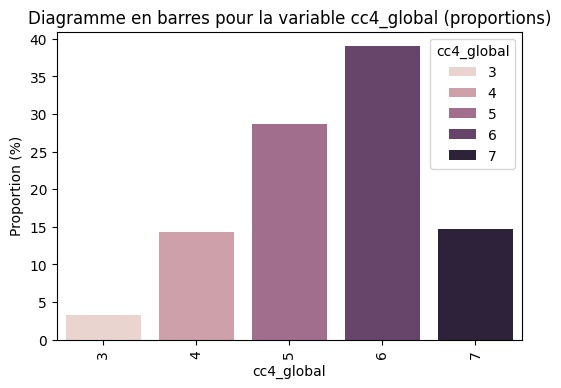

In [558]:
data['cc4_global'] = data[cols].sum(axis=1)
display(data)

for col in ["cc4_global"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### Score cas clinique global

,ID_reponse,Date_de_soumission,Dernière_page,Langue_de_départ,Tête_de_série,Date_de_lancement,Date_de_la_dernière_action,age,sexe,departement,...,c9,c10,c11,score_connaissance,nb_moyen_prevention,cc1_global,cc2_global,cc3_global,cc4_global,score_cc
1,4,2025-10-10 12:28:08,5.0,fr,297730992,2025-10-10 12:18:00,2025-10-10 12:28:08,30,Féminin,44,...,1,0,1,10.000000,12,4,6,4,4,18
2,5,2025-10-10 12:45:36,5.0,fr,1020534482,2025-10-10 12:30:40,2025-10-10 12:45:36,31,Féminin,37,...,1,1,0,7.833333,14,4,4,5,5,18
4,8,2025-10-11 14:52:12,5.0,fr,1458571634,2025-10-11 14:41:17,2025-10-11 14:52:12,39,Féminin,97,...,0,1,0,8.000000,13,7,7,4,6,24
5,9,2025-10-11 16:24:09,5.0,fr,994807669,2025-10-11 15:00:51,2025-10-11 16:24:09,36,Féminin,56,...,0,1,1,8.666667,7,2,7,6,6,21
7,11,2025-10-11 15:49:23,5.0,fr,270610171,2025-10-11 15:30:41,2025-10-11 15:49:23,39,Féminin,26,...,1,1,1,8.833333,12,5,8,4,5,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,558,2026-05-05 19:52:02,5.0,fr,289169349,2026-05-05 19:45:12,2026-05-05 19:52:02,36,Féminin,78,...,0,0,1,4.500000,13,3,4,5,5,17
554,560,2026-05-06 10:42:21,5.0,fr,1222549056,2026-05-06 10:34:14,2026-05-06 10:42:21,23,Féminin,56,...,1,1,0,4.500000,16,5,5,5,6,21
555,561,2026-05-07 08:28:21,5.0,fr,2081938582,2026-05-07 08:17:41,2026-05-07 08:28:21,30,Féminin,38,...,0,0,1,7.833333,13,6,6,4,7,23
556,562,2026-05-07 08:41:12,5.0,fr,943305569,2026-05-07 08:31:23,2026-05-07 08:41:12,31,Masculin,38,...,1,1,1,7.000000,14,4,6,5,7,22


count    300.000000
mean      20.926667
std        2.915984
min       11.000000
25%       19.000000
50%       21.000000
75%       23.000000
max       27.000000
Name: score_cc, dtype: float64

,proportions,valeurs
score_cc,,
21,14.666667,44
19,13.333333,40
22,11.333333,34
24,11.000000,33
20,10.333333,31
23,9.000000,27
18,7.666667,23
25,7.000000,21
17,4.333333,13


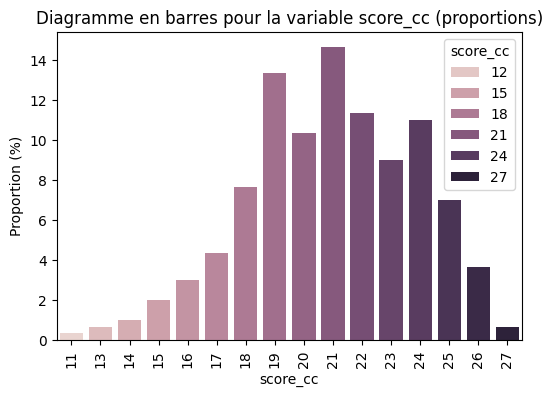

In [559]:
data["score_cc"] = data["cc1_global"] + data["cc2_global"] + data["cc3_global"] + data["cc4_global"]
display(data)

for col in ["score_cc"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

### INTERET POUR UNE FORMATION ###

count     245
unique      2
top       Oui
freq      186
Name: interet_formation, dtype: object

,proportions,valeurs
interet_formation,,
Oui,75.918367,186
Non,24.081633,59


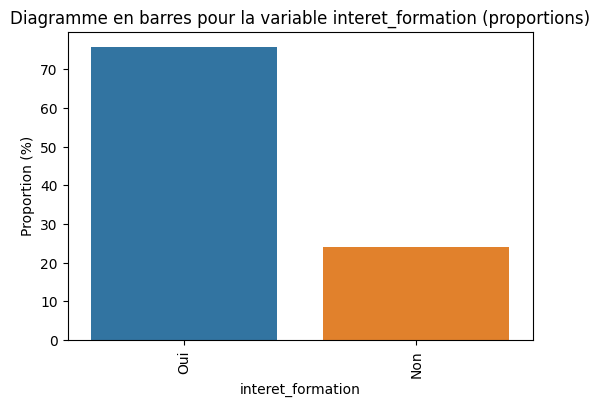

In [560]:
for col in ["interet_formation"]:
    display(data[col].describe())
    plt.figure(figsize=(6, 4))
    proportions = data[col].value_counts(normalize=True) * 100
    values = data[col].value_counts()
    df = pd.DataFrame({ "proportions": proportions, "valeurs": values })
    display(df)

    sns.barplot(x=proportions.index, y=proportions.values, hue=proportions.index)
    plt.title(f"Diagramme en barres pour la variable {col} (proportions)")
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=90)
    plt.show()

## TESTS STATISTIQUES

### CHI2 : avoir des enfants de > 4 ans et déclarer des ATCD de brûlure ###

In [561]:
data_ATCD = pd.pivot_table(data=data, values="ID_reponse", columns="avec_enfant_plus_4_ans", index="ATCD", aggfunc="count")
display(data_ATCD)

avec_enfant_plus_4_ans,0,1
ATCD,,
Non,156,97
Oui,21,26


In [562]:
chi_squared_result=chi2_contingency(data_ATCD)
alpha = 0.05

print("\033[1;32mTest du Chi2 :\033[0m")
print("La statistique de Pearson du test khi-deux est : ", chi_squared_result[0], "\n"
      "La p-valeur du test est : ", chi_squared_result[1], "\n"
      "Nombre de degré de liberté : ", chi_squared_result[2], "\n")
print("Le quantile de la loi du chi 2 à", chi_squared_result[2], "degré de liberté associé au niveau de confiance",alpha,"est",chi2.ppf(1-alpha, chi_squared_result[2]) , "\n")

print("Valeurs attendues : \n", chi_squared_result[3])

Test du Chi2 :
La statistique de Pearson du test khi-deux est :  4.048024203867227 
La p-valeur du test est :  0.044223075313922576 
Nombre de degré de liberté :  1 

Le quantile de la loi du chi 2 à 1 degré de liberté associé au niveau de confiance 0.05 est 3.8414588206941205 

Valeurs attendues : 
 [[149.27 103.73]
 [ 27.73  19.27]]


### CHI2 : évocation spontanée des brûlures et ATCD de brûlure ###

In [563]:
data_brulure_spontanee = pd.pivot_table(data=data, values="ID_reponse", columns="brulure_spontane", index="ATCD", aggfunc="count")
display(data_brulure_spontanee)

brulure_spontane,0,1
ATCD,,
Non,100,153
Oui,13,34


In [564]:
chi_squared_result=chi2_contingency(data_brulure_spontanee)
alpha = 0.05

print("\033[1;32mTest du Chi2 :\033[0m")
print("La statistique de Pearson du test khi-deux est : ", chi_squared_result[0], "\n"
      "La p-valeur du test est : ", chi_squared_result[1], "\n"
      "Nombre de degré de liberté : ", chi_squared_result[2], "\n")
print("Le quantile de la loi du chi 2 à", chi_squared_result[2], "degré de liberté associé au niveau de confiance",alpha,"est",chi2.ppf(1-alpha, chi_squared_result[2]) , "\n")

print("Valeurs attendues : \n", chi_squared_result[3])

Test du Chi2 :
La statistique de Pearson du test khi-deux est :  1.8985104795435328 
La p-valeur du test est :  0.16824513855410414 
Nombre de degré de liberté :  1 

Le quantile de la loi du chi 2 à 1 degré de liberté associé au niveau de confiance 0.05 est 3.8414588206941205 

Valeurs attendues : 
 [[ 95.29666667 157.70333333]
 [ 17.70333333  29.29666667]]


### CHI2 : Formation en santé et ATCD de brûlure ###

In [565]:
data_sante_atcd = pd.pivot_table(data=data, values="ID_reponse", columns="formation_sante", index="ATCD", aggfunc="count")
display(data_sante_atcd)

chi_squared_result=chi2_contingency(data_sante_atcd)
alpha = 0.05

print("\033[1;32mTest du Chi2 :\033[0m")
print("La statistique de Pearson du test khi-deux est : ", chi_squared_result[0], "\n"
      "La p-valeur du test est : ", chi_squared_result[1], "\n"
      "Nombre de degré de liberté : ", chi_squared_result[2], "\n")
print("Le quantile de la loi du chi 2 à", chi_squared_result[2], "degré de liberté associé au niveau de confiance",alpha,"est",chi2.ppf(1-alpha, chi_squared_result[2]) , "\n")

print("Valeurs attendues : \n", chi_squared_result[3])

formation_sante,Non,Oui
ATCD,,
Non,164,89
Oui,28,19


Test du Chi2 :
La statistique de Pearson du test khi-deux est :  0.2733597538754797 
La p-valeur du test est :  0.6010868735303443 
Nombre de degré de liberté :  1 

Le quantile de la loi du chi 2 à 1 degré de liberté associé au niveau de confiance 0.05 est 3.8414588206941205 

Valeurs attendues : 
 [[161.92  91.08]
 [ 30.08  16.92]]


### NIVEAU SOCIAL PERÇU ET ATCD DE BRULURE

In [566]:
data_sante_atcd = pd.pivot_table(data=data, values="ID_reponse", columns="ATCD", index="social", aggfunc="count")
display(data_sante_atcd)

chi_squared_result=chi2_contingency(data_sante_atcd)
alpha = 0.05

print("\033[1;32mTest du Chi2 :\033[0m")
print("La statistique de Pearson du test khi-deux est : ", chi_squared_result[0], "\n"
      "La p-valeur du test est : ", chi_squared_result[1], "\n"
      "Nombre de degré de liberté : ", chi_squared_result[2], "\n")
print("Le quantile de la loi du chi 2 à", chi_squared_result[2], "degré de liberté associé au niveau de confiance",alpha,"est",chi2.ppf(1-alpha, chi_squared_result[2]) , "\n")

print("Valeurs attendues : \n", chi_squared_result[3])

ATCD,Non,Oui
social,,
2,NaN,1.0
3,2.0,2.0
4,7.0,2.0
5,27.0,10.0
6,50.0,7.0
7,89.0,16.0
8,59.0,8.0
9,13.0,1.0
10,6.0,NaN


Test du Chi2 :
La statistique de Pearson du test khi-deux est :  nan 
La p-valeur du test est :  nan 
Nombre de degré de liberté :  8 

Le quantile de la loi du chi 2 à 8 degré de liberté associé au niveau de confiance 0.05 est 15.507313055865453 

Valeurs attendues : 
 [[nan nan]
 [nan nan]
 [nan nan]
 [nan nan]
 [nan nan]
 [nan nan]
 [nan nan]
 [nan nan]
 [nan nan]]


Le chi2 n'est pas réalisable car effectifs des groupes sont inférieurs à 5. 

### NIVEAU SOCIAL PERÇU ET AUTO-EVAL CONNAISSANCES

In [567]:
data_sante_atcd = pd.pivot_table(data=data, values="ID_reponse", columns="niveau_information", index="social", aggfunc="count")
display(data_sante_atcd)

chi_squared_result=chi2_contingency(data_sante_atcd)
alpha = 0.05

print("\033[1;32mTest du Chi2 :\033[0m")
print("La statistique de Pearson du test khi-deux est : ", chi_squared_result[0], "\n"
      "La p-valeur du test est : ", chi_squared_result[1], "\n"
      "Nombre de degré de liberté : ", chi_squared_result[2], "\n")
print("Le quantile de la loi du chi 2 à", chi_squared_result[2], "degré de liberté associé au niveau de confiance",alpha,"est",chi2.ppf(1-alpha, chi_squared_result[2]) , "\n")

print("Valeurs attendues : \n", chi_squared_result[3])

niveau_information,0,1,2,3,4,5
social,,,,,,
2,NaN,NaN,NaN,NaN,1.0,NaN
3,NaN,NaN,NaN,2.0,1.0,1.0
4,NaN,2.0,2.0,1.0,1.0,3.0
5,3.0,6.0,3.0,8.0,11.0,6.0
6,3.0,3.0,5.0,18.0,16.0,12.0
7,1.0,1.0,22.0,26.0,38.0,17.0
8,3.0,6.0,6.0,19.0,19.0,14.0
9,NaN,1.0,1.0,3.0,5.0,4.0
10,NaN,NaN,2.0,2.0,1.0,1.0


Test du Chi2 :
La statistique de Pearson du test khi-deux est :  nan 
La p-valeur du test est :  nan 
Nombre de degré de liberté :  40 

Le quantile de la loi du chi 2 à 40 degré de liberté associé au niveau de confiance 0.05 est 55.75847927888702 

Valeurs attendues : 
 [[nan nan nan nan nan nan]
 [nan nan nan nan nan nan]
 [nan nan nan nan nan nan]
 [nan nan nan nan nan nan]
 [nan nan nan nan nan nan]
 [nan nan nan nan nan nan]
 [nan nan nan nan nan nan]
 [nan nan nan nan nan nan]
 [nan nan nan nan nan nan]]


Le chi2 n'est pas réalisable car effectifs des groupes sont inférieurs à 5. 

### NIVEAU D'INFORMATION PERÇU ET SOURCE D'INFORMATION

Pas possible avec un Chi2 car variables non indépendantes (une personne peut avoir plusieurs sources d'information). 

### LIEN ENTRE LE SCORE DE CONNAISSANCE ET LES SCORES AUX CAS CLINIQUES

In [568]:
r, p = pearsonr(data["score_connaissance"], data["cc1_global"])

print("\033[1;32mTest du Pearson :\033[0m")
print("Le coefficient de corrélation est : ", r, "\n"
      "La p-valeur du test est : ", p, "\n")

Test du Pearson :
Le coefficient de corrélation est :  0.10063273816137862 
La p-valeur du test est :  0.08183205482079742 



In [569]:
r, p = pearsonr(data["score_connaissance"], data["cc2_global"])

print("\033[1;32mTest du Pearson :\033[0m")
print("Le coefficient de corrélation est : ", r, "\n"
      "La p-valeur du test est : ", p, "\n")

Test du Pearson :
Le coefficient de corrélation est :  0.20856511914054282 
La p-valeur du test est :  0.00027534539903367137 



In [570]:
r, p = pearsonr(data["score_connaissance"], data["cc3_global"])

print("\033[1;32mTest du Pearson :\033[0m")
print("Le coefficient de corrélation est : ", r, "\n"
      "La p-valeur du test est : ", p, "\n")

Test du Pearson :
Le coefficient de corrélation est :  0.0603156349492151 
La p-valeur du test est :  0.29774353816678717 



In [571]:
r, p = pearsonr(data["score_connaissance"], data["cc4_global"])

print("\033[1;32mTest du Pearson :\033[0m")
print("Le coefficient de corrélation est : ", r, "\n"
      "La p-valeur du test est : ", p, "\n")

Test du Pearson :
Le coefficient de corrélation est :  0.14772251866690594 
La p-valeur du test est :  0.010406573704891304 



Donc des corrélations positives et statistiquement significative pour les cas cliniques 2 et 4 mais la corrélation est faible. 

In [572]:
r, p = pearsonr(data["score_connaissance"], data["score_cc"])

print("\033[1;32mTest du Pearson :\033[0m")
print("Le coefficient de corrélation est : ", r, "\n"
      "La p-valeur du test est : ", p, "\n")

Test du Pearson :
Le coefficient de corrélation est :  0.21417212975213995 
La p-valeur du test est :  0.00018582663383700097 



### Nombre d'enfant et ATCD de brûlure

In [573]:
groupes = data.groupby('ATCD')["nb_enfants"]

groupe_ATCD = groupes.get_group("Oui")
groupe_no_ATCD = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_ATCD, groupe_no_ATCD, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

t = 0.5735342570107206
p = 0.5682221813344


### Score de connaissance et niveau d'information

In [574]:
r, p = pearsonr(data["score_connaissance"], data["niveau_information"])

print("\033[1;32mTest du Pearson :\033[0m")
print("Le coefficient de corrélation est : ", r, "\n"
      "La p-valeur du test est : ", p, "\n")

Test du Pearson :
Le coefficient de corrélation est :  0.21265327153239533 
La p-valeur du test est :  0.00020692159523909306 



### Score de connaissance et nombre de moyens de prévention

In [575]:
r, p = pearsonr(data["score_connaissance"], data["nb_moyen_prevention"])

print("\033[1;32mTest du Pearson :\033[0m")
print("Le coefficient de corrélation est : ", r, "\n"
      "La p-valeur du test est : ", p, "\n")

Test du Pearson :
Le coefficient de corrélation est :  0.11078112854366395 
La p-valeur du test est :  0.05527878241924676 



### Lien entre la formation professionnalisante santé et les scores de connaissance

In [576]:
groupes = data.groupby('formation_sante')["score_connaissance"]

groupe_formation_sante = groupes.get_group("Oui")
groupe_sans_formation_sante = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_formation_sante, groupe_sans_formation_sante, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

t = 2.8974114924642573
p = 0.004101723821899668


Le groupe ayant une formation en santé a une moyenne aux scores de connaissance plus élevé que le groupe sans formation.

In [577]:
print("Moyenne du groupe ayant une formation en santé : ", groupe_formation_sante.mean())
print("Moyenne du groupe sans formation : ", groupe_sans_formation_sante.mean())

Moyenne du groupe ayant une formation en santé :  8.382716049382715
Moyenne du groupe sans formation :  7.933159722222222


### Lien entre la formation professionnalisante en santé et score au cas clinique 1

In [578]:
groupes = data.groupby('formation_sante')["cc1_global"]

groupe_formation_sante = groupes.get_group("Oui")
groupe_sans_formation_sante = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_formation_sante, groupe_sans_formation_sante, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe ayant une formation en santé : ", groupe_formation_sante.mean())
print("Moyenne du groupe sans formation : ", groupe_sans_formation_sante.mean())

t = 3.024896634854089
p = 0.0028154133803144255
Moyenne du groupe ayant une formation en santé :  4.898148148148148
Moyenne du groupe sans formation :  4.421875


### Lien entre la formation professionnalisante en santé et score au cas clinique 2

In [579]:
groupes = data.groupby('formation_sante')["cc2_global"]

groupe_formation_sante = groupes.get_group("Oui")
groupe_sans_formation_sante = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_formation_sante, groupe_sans_formation_sante, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe ayant une formation en santé : ", groupe_formation_sante.mean())
print("Moyenne du groupe sans formation : ", groupe_sans_formation_sante.mean())

t = 4.296311462806564
p = 2.5371846970400012e-05
Moyenne du groupe ayant une formation en santé :  6.666666666666667
Moyenne du groupe sans formation :  5.96875


### Lien entre la formation professionnalisante en santé et score au cas clinique 3

In [580]:
groupes = data.groupby('formation_sante')["cc3_global"]

groupe_formation_sante = groupes.get_group("Oui")
groupe_sans_formation_sante = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_formation_sante, groupe_sans_formation_sante, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe ayant une formation en santé : ", groupe_formation_sante.mean())
print("Moyenne du groupe sans formation : ", groupe_sans_formation_sante.mean())

t = 3.7736211839179536
p = 0.00020398665492719637
Moyenne du groupe ayant une formation en santé :  4.87037037037037
Moyenne du groupe sans formation :  4.510416666666667


### Lien entre la formation professionnalisante en santé et score au cas clinique 4

In [581]:
groupes = data.groupby('formation_sante')["cc4_global"]

groupe_formation_sante = groupes.get_group("Oui")
groupe_sans_formation_sante = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_formation_sante, groupe_sans_formation_sante, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe ayant une formation en santé : ", groupe_formation_sante.mean())
print("Moyenne du groupe sans formation : ", groupe_sans_formation_sante.mean())

t = 0.8588947679983752
p = 0.3911944633419079
Moyenne du groupe ayant une formation en santé :  5.537037037037037
Moyenne du groupe sans formation :  5.4375


### Lien entre la formation professionnalisante en santé et score global aux cas cliniques

In [582]:
groupes = data.groupby('formation_sante')["score_cc"]

groupe_formation_sante = groupes.get_group("Oui")
groupe_sans_formation_sante = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_formation_sante, groupe_sans_formation_sante, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe ayant une formation en santé : ", groupe_formation_sante.mean())
print("Moyenne du groupe sans formation : ", groupe_sans_formation_sante.mean())

t = 4.889282542200105
p = 1.898570869944693e-06
Moyenne du groupe ayant une formation en santé :  21.97222222222222
Moyenne du groupe sans formation :  20.338541666666668


### Lien entre travail dans la petite enfance et score de connaissance

In [583]:
groupes = data.groupby('travail_enfance')["score_connaissance"]

groupe_travail_enfance = groupes.get_group("Oui")
groupe_sans_travail_enfance = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_travail_enfance, groupe_sans_travail_enfance, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe travaillant dans la petite enfance : ", groupe_travail_enfance.mean())
print("Moyenne du groupe ne travaillant pas dans la petite enfance : ", groupe_sans_travail_enfance.mean())

t = 2.0014923587468276
p = 0.05194538128905248
Moyenne du groupe travaillant dans la petite enfance :  8.52020202020202
Moyenne du groupe ne travaillant pas dans la petite enfance :  8.042446941323346


### Lien entre travail dans la petite enfance et score au cas clinique 1

In [584]:
groupes = data.groupby('travail_enfance')["cc1_global"]

groupe_travail_enfance = groupes.get_group("Oui")
groupe_sans_travail_enfance = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_travail_enfance, groupe_sans_travail_enfance, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe travaillant dans la petite enfance : ", groupe_travail_enfance.mean())
print("Moyenne du groupe ne travaillant pas dans la petite enfance : ", groupe_sans_travail_enfance.mean())

t = 1.7014483499389763
p = 0.09706246964903369
Moyenne du groupe travaillant dans la petite enfance :  5.0
Moyenne du groupe ne travaillant pas dans la petite enfance :  4.543071161048689


### Lien entre travail dans la petite enfance et score au cas clinique 2

In [585]:
groupes = data.groupby('travail_enfance')["cc2_global"]

groupe_travail_enfance = groupes.get_group("Oui")
groupe_sans_travail_enfance = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_travail_enfance, groupe_sans_travail_enfance, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe travaillant dans la petite enfance : ", groupe_travail_enfance.mean())
print("Moyenne du groupe ne travaillant pas dans la petite enfance : ", groupe_sans_travail_enfance.mean())

t = 1.4535315436683154
p = 0.1540259554786911
Moyenne du groupe travaillant dans la petite enfance :  6.575757575757576
Moyenne du groupe ne travaillant pas dans la petite enfance :  6.176029962546816


### Lien entre travail dans la petite enfance et score au cas clinique 3

In [586]:
groupes = data.groupby('travail_enfance')["cc3_global"]

groupe_travail_enfance = groupes.get_group("Oui")
groupe_sans_travail_enfance = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_travail_enfance, groupe_sans_travail_enfance, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe travaillant dans la petite enfance : ", groupe_travail_enfance.mean())
print("Moyenne du groupe ne travaillant pas dans la petite enfance : ", groupe_sans_travail_enfance.mean())

t = -0.5404151061392571
p = 0.5916437812804558
Moyenne du groupe travaillant dans la petite enfance :  4.575757575757576
Moyenne du groupe ne travaillant pas dans la petite enfance :  4.647940074906367


### Lien entre travail dans la petite enfance et score au cas clinique 4

In [587]:
groupes = data.groupby('travail_enfance')["cc4_global"]

groupe_travail_enfance = groupes.get_group("Oui")
groupe_sans_travail_enfance = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_travail_enfance, groupe_sans_travail_enfance, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe travaillant dans la petite enfance : ", groupe_travail_enfance.mean())
print("Moyenne du groupe ne travaillant pas dans la petite enfance : ", groupe_sans_travail_enfance.mean())

t = 0.8560844735883102
p = 0.3967897926437197
Moyenne du groupe travaillant dans la petite enfance :  5.606060606060606
Moyenne du groupe ne travaillant pas dans la petite enfance :  5.456928838951311


### Lien entre travail dans la petite enfance et score global aux cas cliniques

In [588]:
groupes = data.groupby('travail_enfance')["score_cc"]

groupe_travail_enfance = groupes.get_group("Oui")
groupe_sans_travail_enfance = groupes.get_group("Non")

t_stat, p_value = stats.ttest_ind(groupe_travail_enfance, groupe_sans_travail_enfance, equal_var=False)

print("t =", t_stat)
print("p =", p_value)

print("Moyenne du groupe travaillant dans la petite enfance : ", groupe_travail_enfance.mean())
print("Moyenne du groupe ne travaillant pas dans la petite enfance : ", groupe_sans_travail_enfance.mean())

t = 1.657597861488474
p = 0.10536110087419787
Moyenne du groupe travaillant dans la petite enfance :  21.757575757575758
Moyenne du groupe ne travaillant pas dans la petite enfance :  20.823970037453183
